# ***ANÁLISIS DE VENTAS DE ADIDAS EN USA***

En el siguiente trabajo analizaremos el rendimiento de ventas de Adidas en Estados Unidos a partir de un conjunto de datos reales que recoge información detallada sobre precios, unidades vendidas, beneficios y márgenes operativos por región, ciudad, producto, canal de venta y distribuidor.
El dataset está formado por 9.648 registros y 13 variables, abarca los años 2020 y 2021, lo que permite observar el comportamiento del mercado antes y después del repunte del consumo tras la pandemia.

El objetivo inicial era realizar un análisis exploratorio inicial (EDA) para comprender las principales dinámicas comerciales de la marca. Para ello estudiaremos las tendencias por región y canal, la evolución temporal de las ventas, la rentabilidad por producto y distribuidor y la relación entre variables clave como precio, volumen y beneficio. Posteriormente, desarrollamos un modelo de Machine Learning supervisado con el fin de predecir el número de unidades vendidas a partir de variables como el precio por unidad, la región, el producto, el distribuidor, el método de venta y la fecha (mes y año).
Para evitar filtraciones de información excluímos las variables derivadas de la propia venta, es decir Total Sales, Operating Profit y Operating Margin. Probaremos con varios algoritmos hasta encontrar el mejor.


In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, plot_importance
from scipy.optimize import minimize_scalar

In [7]:
from google.colab import files
uploaded = files.upload()

Saving Adidas US Sales Datasets.xlsx to Adidas US Sales Datasets.xlsx


In [8]:
df = pd.read_excel('Adidas US Sales Datasets.xlsx')
df=df.drop(df.index[:3])
df.columns=df.iloc[0]
df=df.drop(df.index[0])
df=df.drop(df.columns[0],axis=1)
df.head()

3,Retailer,Retailer ID,Invoice Date,Region,State,City,Product,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin,Sales Method
4,Foot Locker,1185732,2020-01-01 00:00:00,Northeast,New York,New York,Men's Street Footwear,50,1200,600000,300000,0.5,In-store
5,Foot Locker,1185732,2020-01-02 00:00:00,Northeast,New York,New York,Men's Athletic Footwear,50,1000,500000,150000,0.3,In-store
6,Foot Locker,1185732,2020-01-03 00:00:00,Northeast,New York,New York,Women's Street Footwear,40,1000,400000,140000,0.35,In-store
7,Foot Locker,1185732,2020-01-04 00:00:00,Northeast,New York,New York,Women's Athletic Footwear,45,850,382500,133875,0.35,In-store
8,Foot Locker,1185732,2020-01-05 00:00:00,Northeast,New York,New York,Men's Apparel,60,900,540000,162000,0.3,In-store


El conjunto de datos venía un poco raro, porque había una foto arriba y eso lo distorsionaba un poco, por tanto al cargarlo eliminamos las filas y columnas vacías.

In [9]:
df.shape

(9648, 13)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 4 to 9651
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Retailer          9648 non-null   object
 1   Retailer ID       9648 non-null   object
 2   Invoice Date      9648 non-null   object
 3   Region            9648 non-null   object
 4   State             9648 non-null   object
 5   City              9648 non-null   object
 6   Product           9648 non-null   object
 7   Price per Unit    9648 non-null   object
 8   Units Sold        9648 non-null   object
 9   Total Sales       9648 non-null   object
 10  Operating Profit  9648 non-null   object
 11  Operating Margin  9648 non-null   object
 12  Sales Method      9648 non-null   object
dtypes: object(13)
memory usage: 980.0+ KB


In [11]:
df.isna().sum()

,0
3,
Retailer,0
Retailer ID,0
Invoice Date,0
Region,0
State,0
City,0
Product,0
Price per Unit,0
Units Sold,0


In [12]:
df["Invoice Date"] = pd.to_datetime(df["Invoice Date"], errors="coerce")

In [13]:
df.describe()

3,Invoice Date
count,9648
mean,2021-05-10 15:20:44.776119296
min,2020-01-01 00:00:00
25%,2021-02-17 00:00:00
50%,2021-06-04 00:00:00
75%,2021-09-16 00:00:00
max,2021-12-31 00:00:00


In [14]:
cols_nums = ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit", "Operating Margin"]

for col in cols_nums:
    df[col] = df[col].replace('[\$,%,]', '', regex=True).astype(float)

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3503332243.py:4: SyntaxWarning: invalid escape sequence '\$'
  df[col] = df[col].replace('[\$,%,]', '', regex=True).astype(float)
/tmp/ipython-input-3503332243.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('[\$,%,]', '', regex=True).astype(float)
/tmp/ipython-input-3503332243.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace('[\$,%,]', '', regex=True).ast

Hemos visto que no hay valores nulos, sin embargo, todas las columnas estaban en tipo 'object', hemos convertido la de fecha a datetime y las numércias a float.

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 4 to 9651
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Retailer          9648 non-null   object        
 1   Retailer ID       9648 non-null   object        
 2   Invoice Date      9648 non-null   datetime64[ns]
 3   Region            9648 non-null   object        
 4   State             9648 non-null   object        
 5   City              9648 non-null   object        
 6   Product           9648 non-null   object        
 7   Price per Unit    9648 non-null   float64       
 8   Units Sold        9648 non-null   float64       
 9   Total Sales       9648 non-null   float64       
 10  Operating Profit  9648 non-null   float64       
 11  Operating Margin  9648 non-null   float64       
 12  Sales Method      9648 non-null   object        
dtypes: datetime64[ns](1), float64(5), object(7)
memory usage: 980.0+ KB


## ***Análisis de las variables indiviudalmente.***

En esta primera parte veremos un poco de todas las variables, tanto numéricas como categóricas, para entender como varían y como afectan.

In [16]:
df.describe()

3,Invoice Date,Price per Unit,Units Sold,Total Sales,Operating Profit,Operating Margin
count,9648,9648.000000,9648.000000,9648.000000,9648.000000,9648.000000
mean,2021-05-10 15:20:44.776119296,45.216625,256.930037,93273.437500,34425.244761,0.422991
min,2020-01-01 00:00:00,7.000000,0.000000,0.000000,0.000000,0.100000
25%,2021-02-17 00:00:00,35.000000,106.000000,4254.500000,1921.752500,0.350000
50%,2021-06-04 00:00:00,45.000000,176.000000,9576.000000,4371.420000,0.410000
75%,2021-09-16 00:00:00,55.000000,350.000000,150000.000000,52062.500000,0.490000
max,2021-12-31 00:00:00,110.000000,1275.000000,825000.000000,390000.000000,0.800000
std,NaN,14.705397,214.252030,141916.016727,54193.113713,0.097197


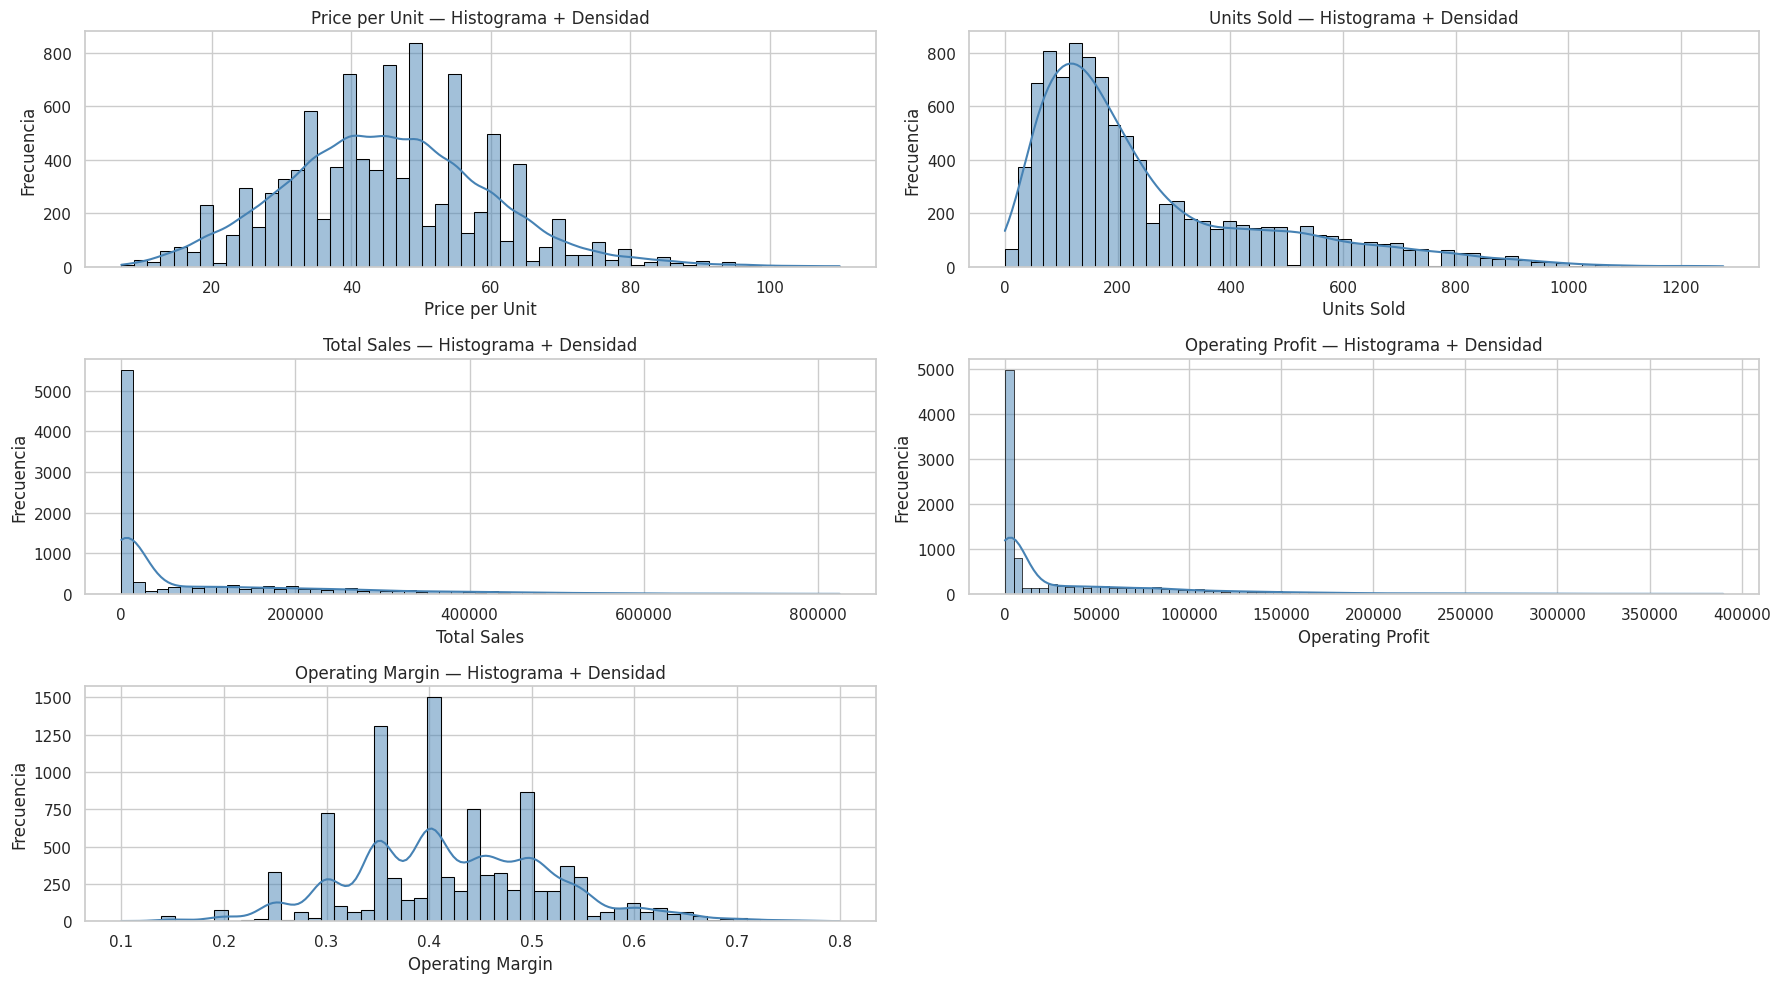

In [21]:
cols = ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit", "Operating Margin"]
for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', alpha=0.5, edgecolor='black')
    axes[i].set_title(f"{col} — Histograma + Densidad")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")
axes[-1].axis("off")

plt.tight_layout()
plt.show()

### ***Regiones***

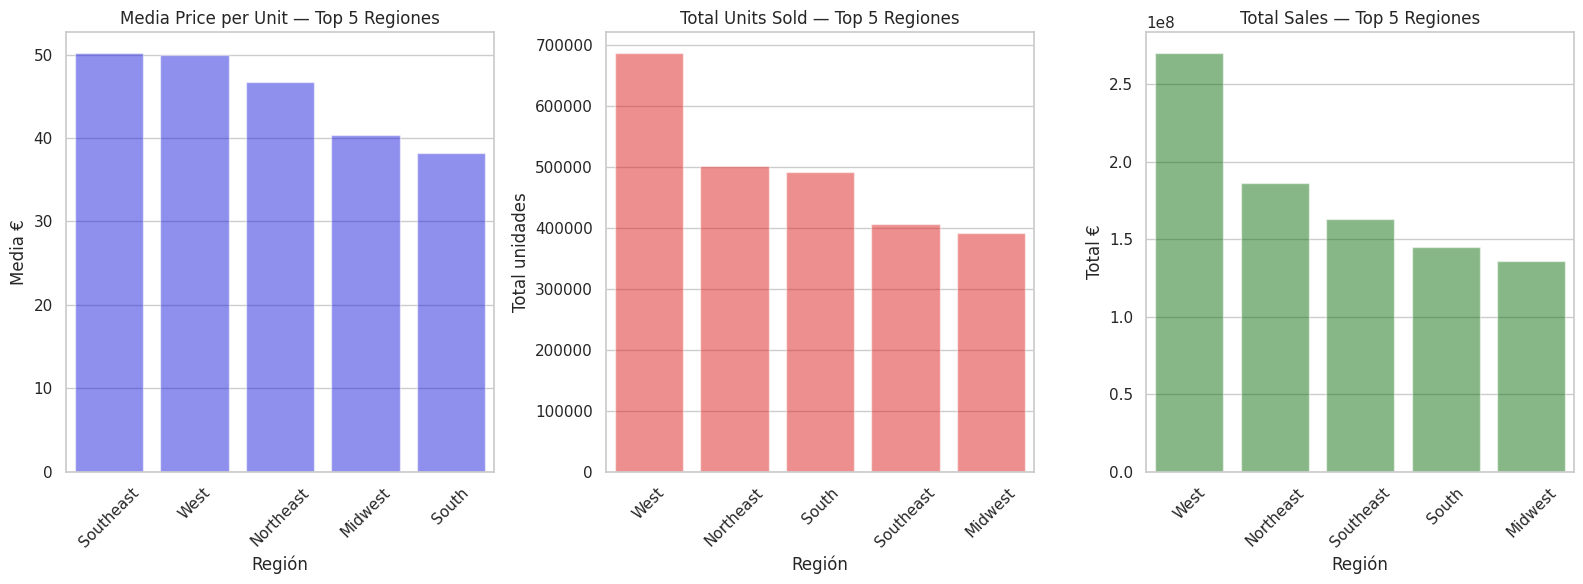

In [24]:
region_means = df.groupby("Region")["Price per Unit"].mean()
region_units = df.groupby("Region")["Units Sold"].sum()
region_sales = df.groupby("Region")["Total Sales"].sum()

top_mean_price = region_means.sort_values(ascending=False)
top_total_units = region_units.sort_values(ascending=False)
top_total_sales = region_sales.sort_values(ascending=False)


sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Precio por unidad
sns.barplot(x=top_mean_price.index, y=top_mean_price.values, ax=axes[0], color='blue', alpha=0.5)
axes[0].set_title("Media Price per Unit — Top 5 Regiones")
axes[0].set_ylabel("Media €")
axes[0].set_xlabel("Región")
axes[0].tick_params(axis='x', rotation=45)

# Unidades vendidas
sns.barplot(x=top_total_units.index, y=top_total_units.values, ax=axes[1], color='red', alpha=0.5)
axes[1].set_title("Total Units Sold — Top 5 Regiones")
axes[1].set_ylabel("Total unidades")
axes[1].set_xlabel("Región")
axes[1].tick_params(axis='x', rotation=45)

# Ventas
sns.barplot(x=top_total_sales.index, y=top_total_sales.values, ax=axes[2], color='green', alpha=0.5)
axes[2].set_title("Total Sales — Top 5 Regiones")
axes[2].set_ylabel("Total €")
axes[2].set_xlabel("Región")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

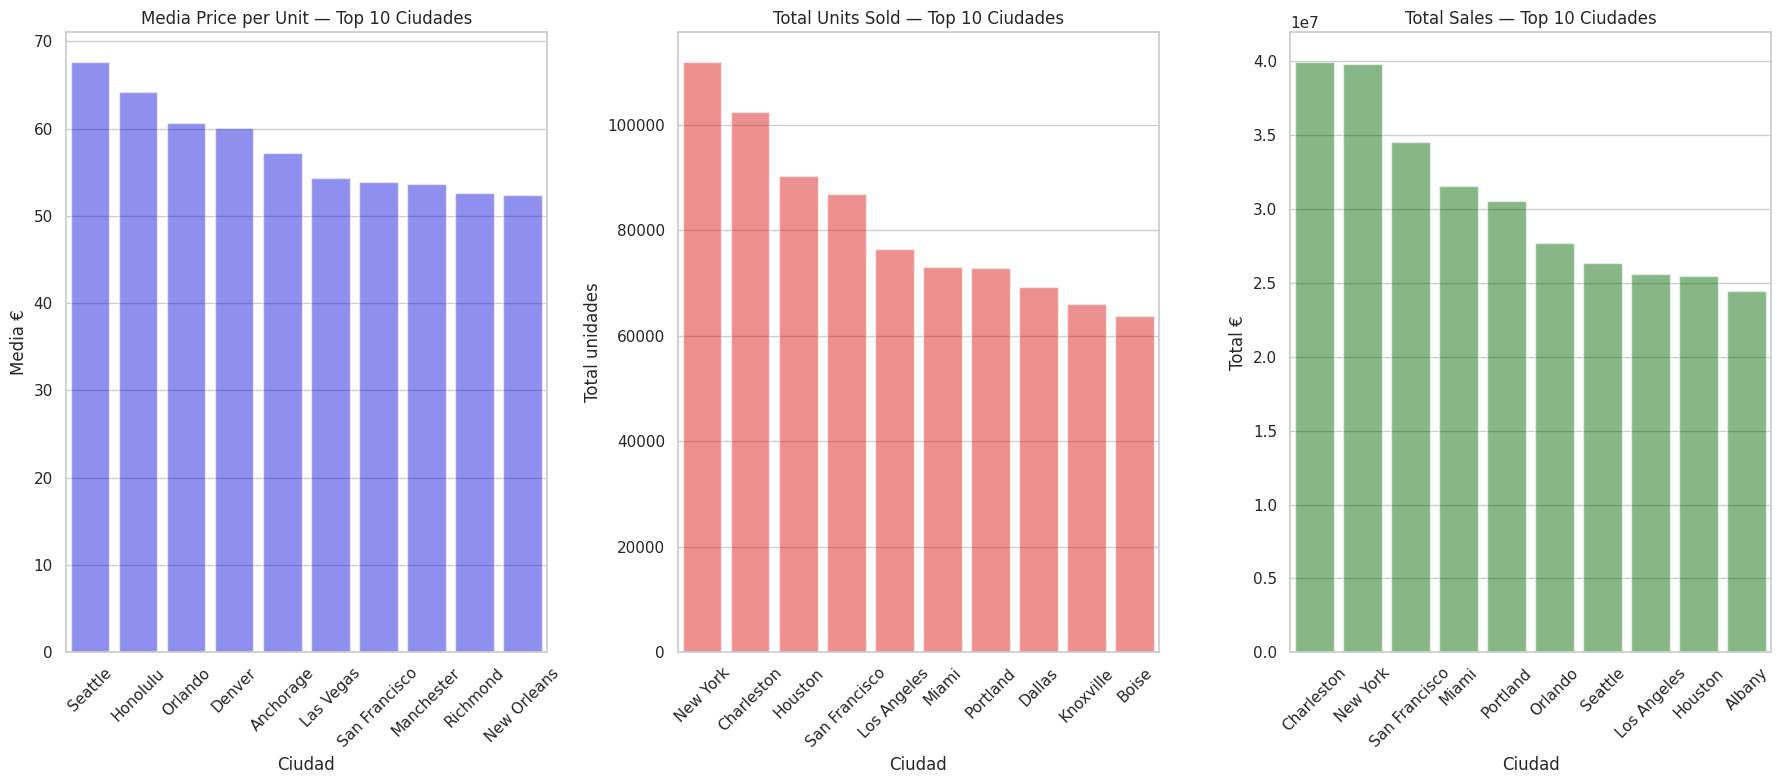

In [25]:
city_means = df.groupby("City")["Price per Unit"].mean()
city_units = df.groupby("City")["Units Sold"].sum()
city_sales = df.groupby("City")["Total Sales"].sum()

# Selección las top 10
top_mean_price = city_means.sort_values(ascending=False).head(10)
top_total_units = city_units.sort_values(ascending=False).head(10)
top_total_sales = city_sales.sort_values(ascending=False).head(10)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

# Precio por unidad
sns.barplot(x=top_mean_price.index, y=top_mean_price.values, ax=axes[0], color='blue', alpha=0.5)
axes[0].set_title("Media Price per Unit — Top 10 Ciudades")
axes[0].set_ylabel("Media €")
axes[0].set_xlabel("Ciudad")
axes[0].tick_params(axis='x', rotation=45)

#Unidades vendidas
sns.barplot(x=top_total_units.index, y=top_total_units.values, ax=axes[1], color='red', alpha=0.5)
axes[1].set_title("Total Units Sold — Top 10 Ciudades")
axes[1].set_ylabel("Total unidades")
axes[1].set_xlabel("Ciudad")
axes[1].tick_params(axis='x', rotation=45)

# Ventas totales
sns.barplot(x=top_total_sales.index, y=top_total_sales.values, ax=axes[2], color='green', alpha=0.5)
axes[2].set_title("Total Sales — Top 10 Ciudades")
axes[2].set_ylabel("Total €")
axes[2].set_xlabel("Ciudad")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Las regiones West y Northeast lideran en ventas totales y volumen, mientras que Southeast presenta un perfil de precios más elevados pero con menor demanda. Esto sugiere que la elasticidad del precio varía según la zona, lo que podría ayudarnos a orientar futuras estrategias de precios y promoción

Por otro lado, en las ciudades observamos tres patrones de mercado: ciudades premium como Seattle o Honolulu con precios elevados y menor volumen, grandes centros urbanos como New York con gran cantidad de ventas pero precios más 'bajos' y mercados intermedios como San Francisco que combinan ambas características.

### ***Métodos de venta***

/tmp/ipython-input-5143764.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Sales Method", y="Operating Margin", data=margin_data, palette="Set2", ax=axes[1])


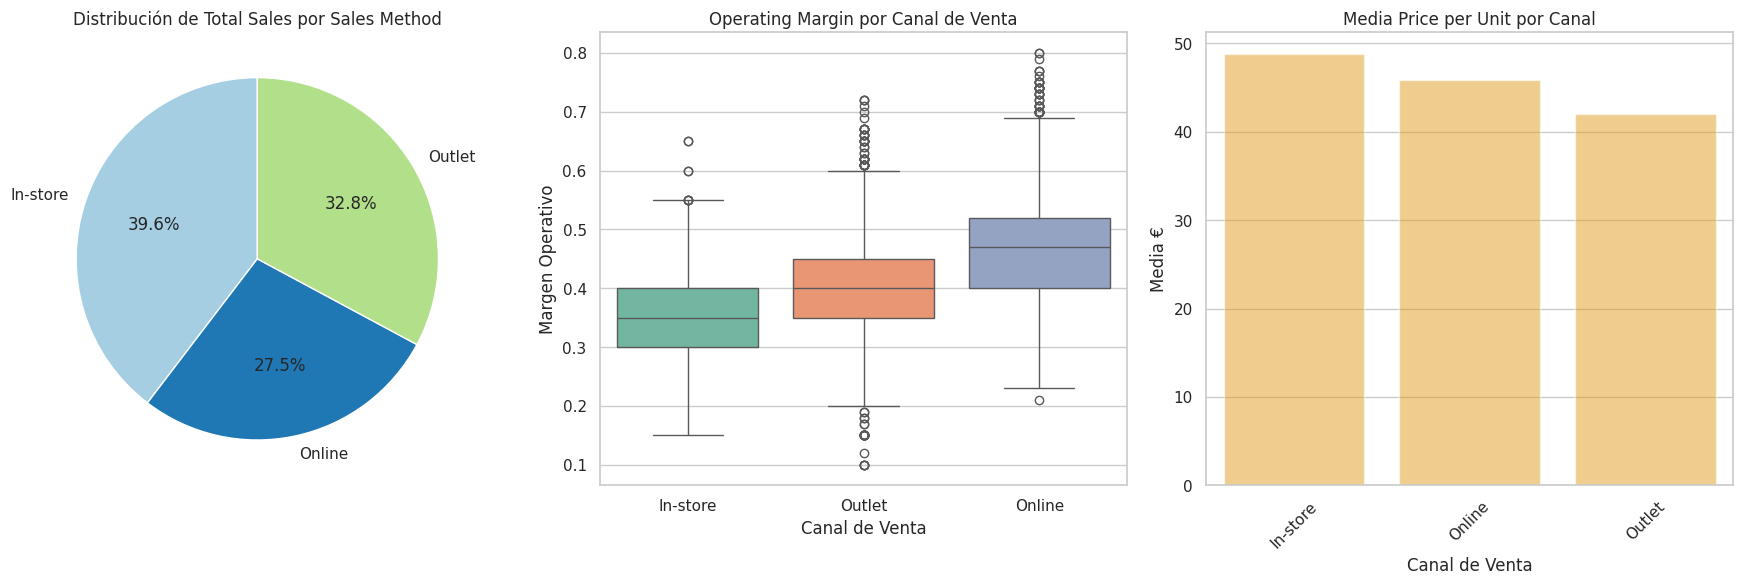

In [26]:
sales_by_method = df.groupby("Sales Method")["Total Sales"].sum()
margin_data = df[["Sales Method", "Operating Margin"]].dropna()
price_means = df.groupby("Sales Method")["Price per Unit"].mean().sort_values(ascending=False)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Ventas totales
axes[0].pie(sales_by_method.values,
            labels=sales_by_method.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=plt.cm.Paired.colors)
axes[0].set_title("Distribución de Total Sales por Sales Method")

# 2. Margen
sns.boxplot(x="Sales Method", y="Operating Margin", data=margin_data, palette="Set2", ax=axes[1])
axes[1].set_title("Operating Margin por Canal de Venta")
axes[1].set_xlabel("Canal de Venta")
axes[1].set_ylabel("Margen Operativo")

# 3. Precio por unidad
sns.barplot(x=price_means.index, y=price_means.values, ax=axes[2], color='orange', alpha=0.5)
axes[2].set_title("Media Price per Unit por Canal")
axes[2].set_xlabel("Canal de Venta")
axes[2].set_ylabel("Media €")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

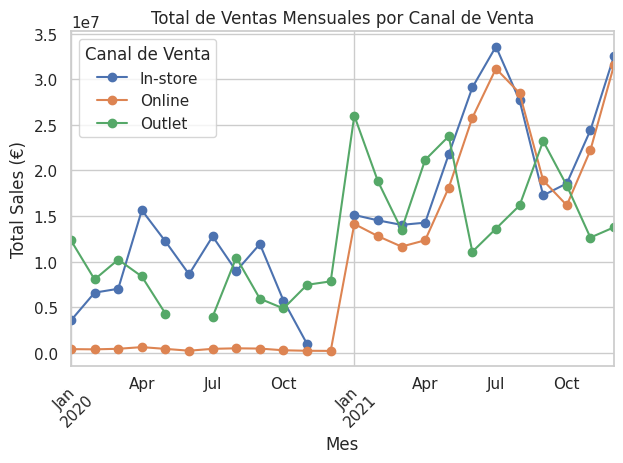

In [30]:
df["Invoice Date"] = pd.to_datetime(df["Invoice Date"], errors='coerce')
df["Month"] = df["Invoice Date"].dt.to_period("M").dt.to_timestamp()
monthly_sales_channel = df.groupby(["Sales Method", "Month"])["Total Sales"].sum().reset_index()
pivot_sales = monthly_sales_channel.pivot(index="Month", columns="Sales Method", values="Total Sales")

plt.figure(figsize=(12, 6))
pivot_sales.plot(marker='o')
plt.title("Total de Ventas Mensuales por Canal de Venta")
plt.xlabel("Mes")
plt.ylabel("Total Sales (€)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend(title="Canal de Venta")
plt.show()

Podemos observar como el canal en tienda física sigue siendo el principal motor de ventas pese al crecimiento del comercio online en los últimos años, sin embargo el online se perfila como el más eficiente en rentabilidad. Destcamos que el canal Outlet, a pesar de ofrecer los precios más bajos, se posiciona como más rentable en términos de margen operativo medio que las tiendas oficiales. Esto sugiere una estrategia eficaz de control de costes o de rotación de inventario. En contraste, las tiendas físicas mantienen precios más altos pero con márgenes más estrechos, lo que apunta a un mayor peso de los costes fijos.

El gráfico nos muestra una ruptura clara en la tendencia a partir de enero de 2021, donde todos los canales experimentan un fuerte crecimiento simultáneo en las ventas totales. Durante 2020, el canal In-store domina con altibajos marcados, mientras que Online y Outlet mantienen volúmenes mucho menores. Sin embargo, tras el salto de 2021, el Online se dispara casi al nivel de las tiendas físicas, reflejando una aceleración del comercio digital posiblemente impulsada por la recuperación pospandemia y el cambio en los hábitos de consumo. El canal Outlet también crece con fuerza, mostrando picos intermitentes que podrían asociarse a campañas de descuentos o liquidación de stock. En conjunto, el gráfico evidencia una reconfiguración del mix de canales, con un equilibrio creciente entre ventas físicas, online y de outlet a lo largo de 2021.

### ***Retailer***

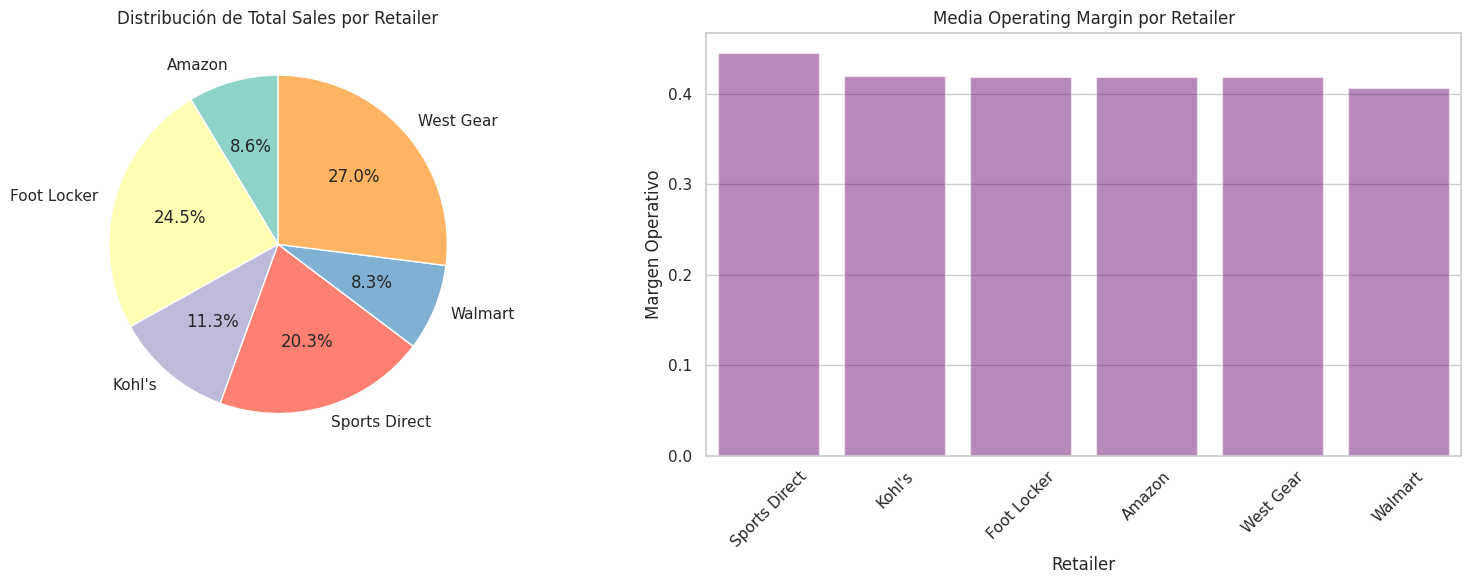

In [32]:
sales_by_retailer = df.groupby("Retailer")["Total Sales"].sum()
margin_by_retailer = df.groupby("Retailer")["Operating Margin"].mean().sort_values(ascending=False)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ventas totales
axes[0].pie(sales_by_retailer.values,
            labels=sales_by_retailer.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=plt.cm.Set3.colors)
axes[0].set_title("Distribución de Total Sales por Retailer")

# Operating margin
sns.barplot(x=margin_by_retailer.index,
            y=margin_by_retailer.values,
            ax=axes[1],
            color='purple',
            alpha=0.5)
axes[1].set_title("Media Operating Margin por Retailer")
axes[1].set_ylabel("Margen Operativo")
axes[1].set_xlabel("Retailer")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Podemos observar como el liderazgo de West Gear y Foot Locker en ventas consolida la fortaleza del canal especializado, pero la mayor rentabilidad de Sports Direct evidencia que un volumen menor puede ser más eficiente. Adidas podría explorar cómo escalar ese modelo rentable de Sports Direct a otros socios o reforzar el canal directo online para capturar parte de esa eficiencia. La baja rentabilidad de Walmart sugiere que el canal generalista, aunque aporta cobertura, no contribuye significativamente a los márgenes globales.

### ***Producto***

/tmp/ipython-input-2258356590.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df,


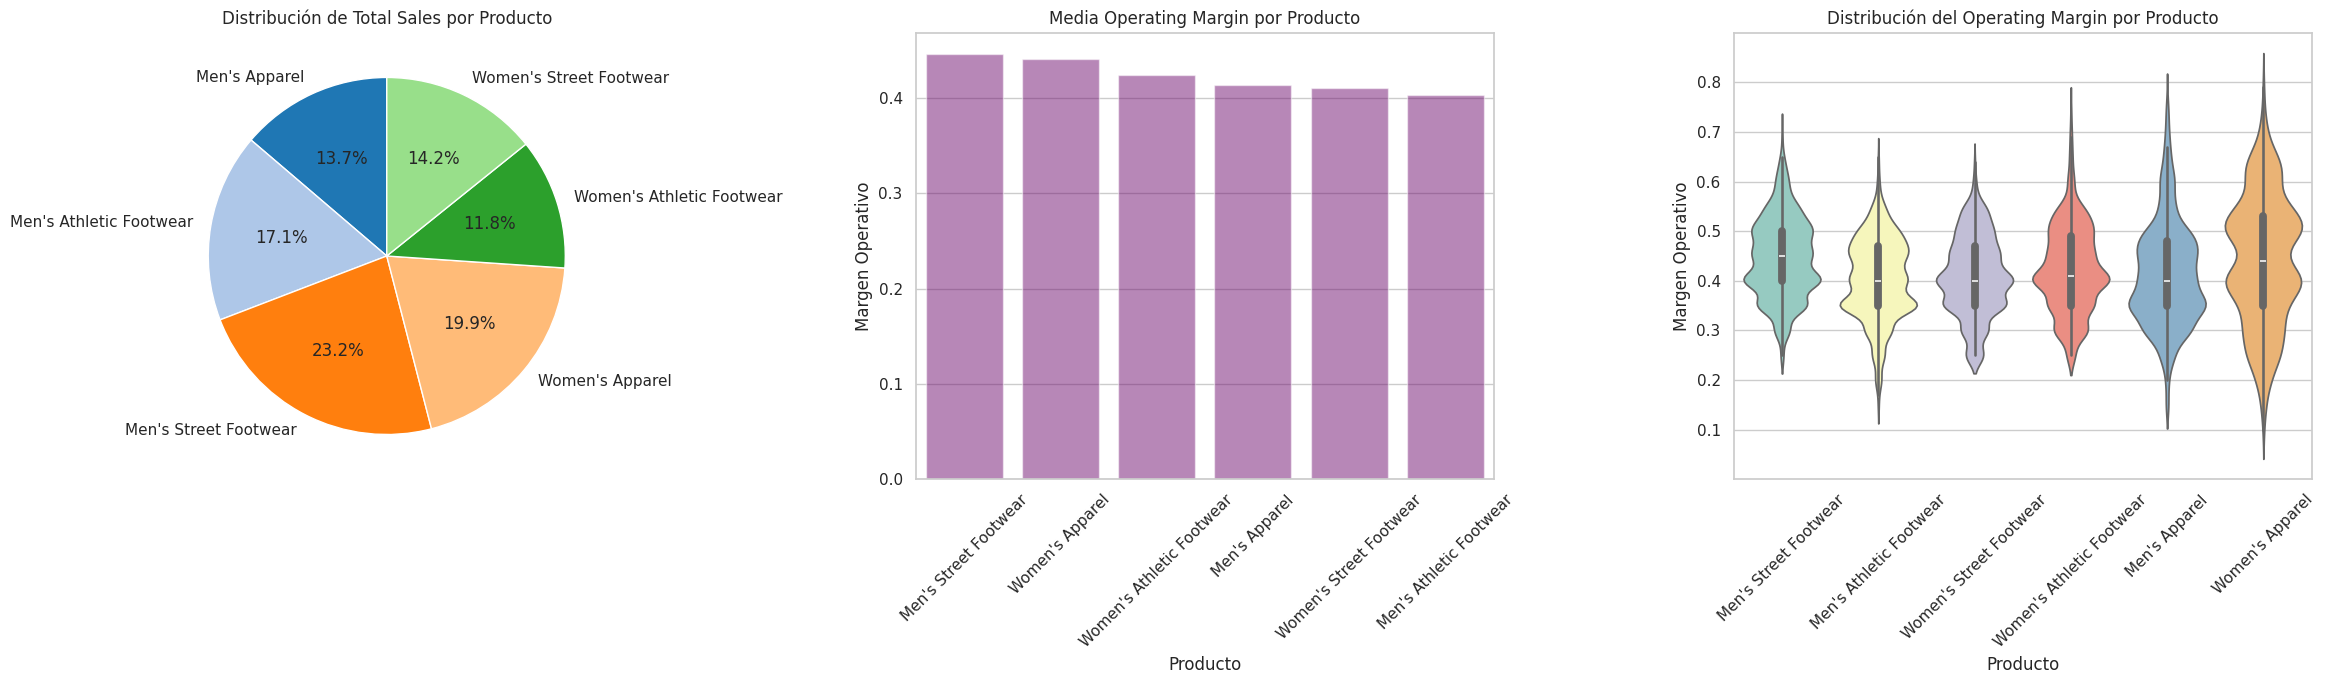

In [33]:
sales_by_product = df.groupby("Product")["Total Sales"].sum()
margin_by_product = df.groupby("Product")["Operating Margin"].mean().sort_values(ascending=False)

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Ventas totales
axes[0].pie(sales_by_product.values,
            labels=sales_by_product.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=plt.cm.tab20.colors)
axes[0].set_title("Distribución de Total Sales por Producto")

# Operating margin
sns.barplot(x=margin_by_product.index,
            y=margin_by_product.values,
            ax=axes[1],
            color='purple',
            alpha=0.5)
axes[1].set_title("Media Operating Margin por Producto")
axes[1].set_ylabel("Margen Operativo")
axes[1].set_xlabel("Producto")
axes[1].tick_params(axis='x', rotation=45)

# Operating Margin (violin)
sns.violinplot(data=df,
               x="Product",
               y="Operating Margin",
               palette="Set3",
               inner="box",
               ax=axes[2])
axes[2].set_title("Distribución del Operating Margin por Producto")
axes[2].set_xlabel("Producto")
axes[2].set_ylabel("Margen Operativo")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipython-input-2633908208.py:29: UserWarning: Glyph 128182 (\N{BANKNOTE WITH EURO SIGN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-2633908208.py:29: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128182 (\N{BANKNOTE WITH EURO SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128182 (\N{BANKNOTE WITH EURO SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from

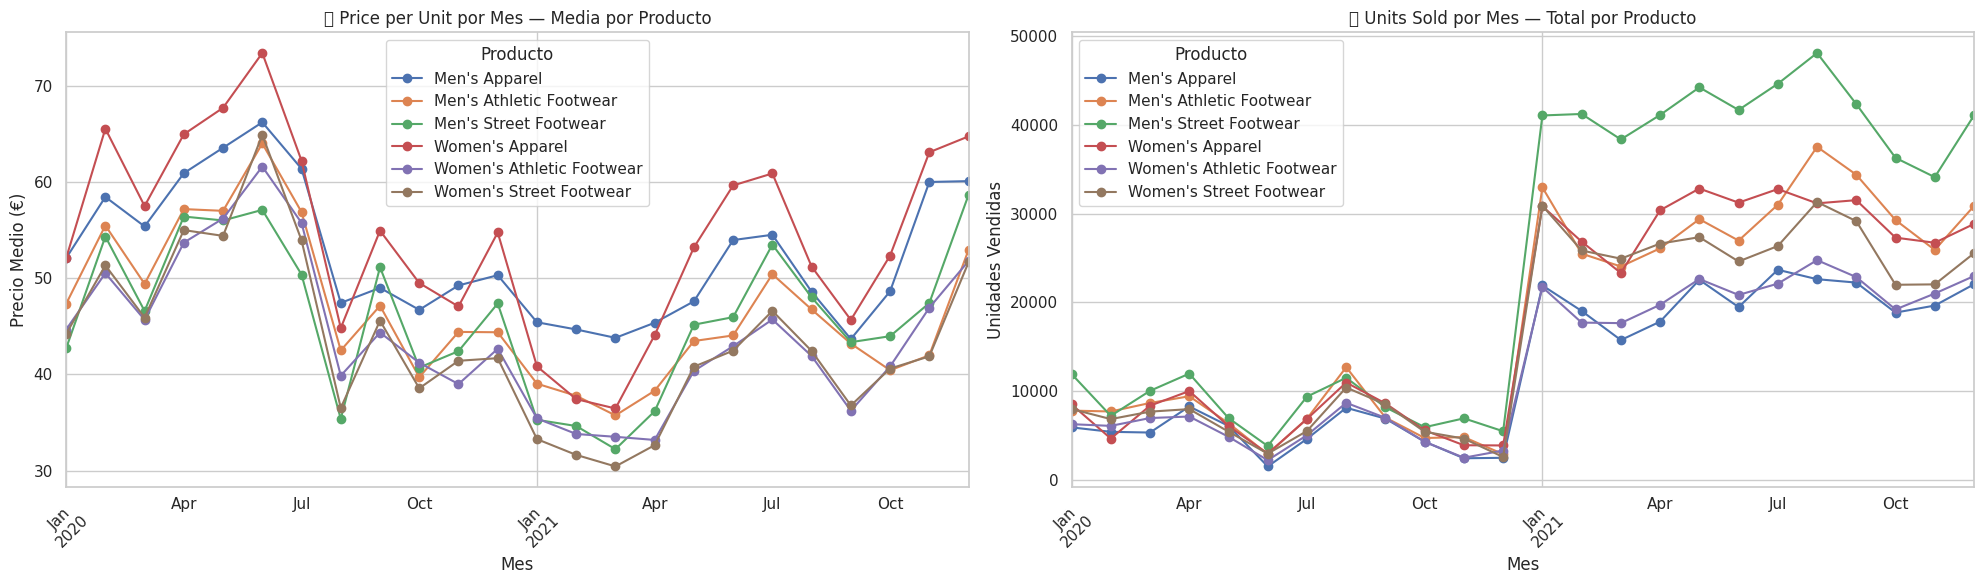

In [43]:
price_by_product = df.groupby(["Product", "Month"])["Price per Unit"].mean().reset_index()
units_by_product = df.groupby(["Product", "Month"])["Units Sold"].sum().reset_index()
price_pivot = price_by_product.pivot(index="Month", columns="Product", values="Price per Unit")
units_pivot = units_by_product.pivot(index="Month", columns="Product", values="Units Sold")


fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Precio medio por unidad
price_pivot.plot(marker='o', ax=axes[0])
axes[0].set_title("Price per Unit por Mes — Media por Producto")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("Precio Medio (€)")
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True)
axes[0].legend(title="Producto")

# Unidades vendidas
units_pivot.plot(marker='o', ax=axes[1])
axes[1].set_title("Units Sold por Mes — Total por Producto")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Unidades Vendidas")
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True)
axes[1].legend(title="Producto")

plt.tight_layout()
plt.show()

Podemos ver como el producto Men's Street Footwear combina liderazgo en ventas y margen operativo, actuando como el motor principal del negocio. En contraste, las líneas atléticas, especialmente la masculina, tienen un peso comercial importante pero menor rentabilidad, probablemente por la competencia en precios y costes de materiales técnicos. Las categorías femeninas, en particular Women's Apparel, exhiben una tendencia positiva tanto en participación como en rentabilidad, consolidándose como áreas de crecimiento estratégico.

Desde la perspectiva temporal, los gráficos reflejan un patrón estacional bien definido: los precios alcanzan su punto máximo a mitad de año, mientras que las unidades vendidas se incrementan en los periodos de precios más bajos, revelando una clara elasticidad precio-demanda. Vemos una subida muy destacada de ventas que sería interesante estudiar, podrá deberse a, como hemos visto antes el comienzo de ventas online.

### ***Tendencias mensuales del negocio***

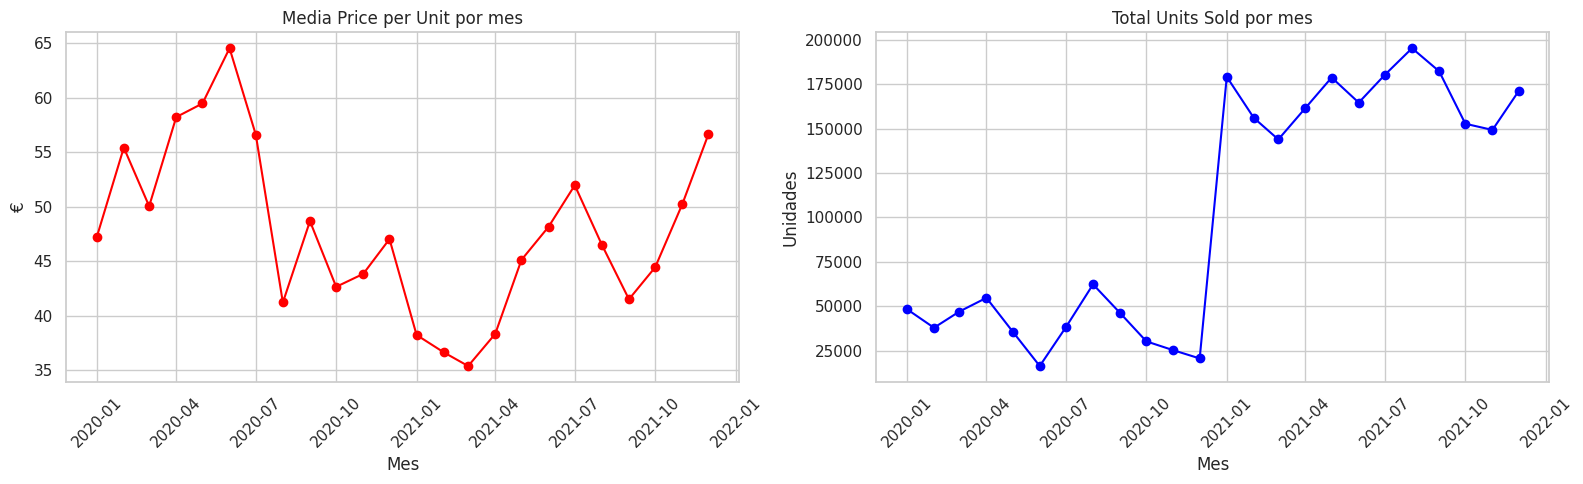

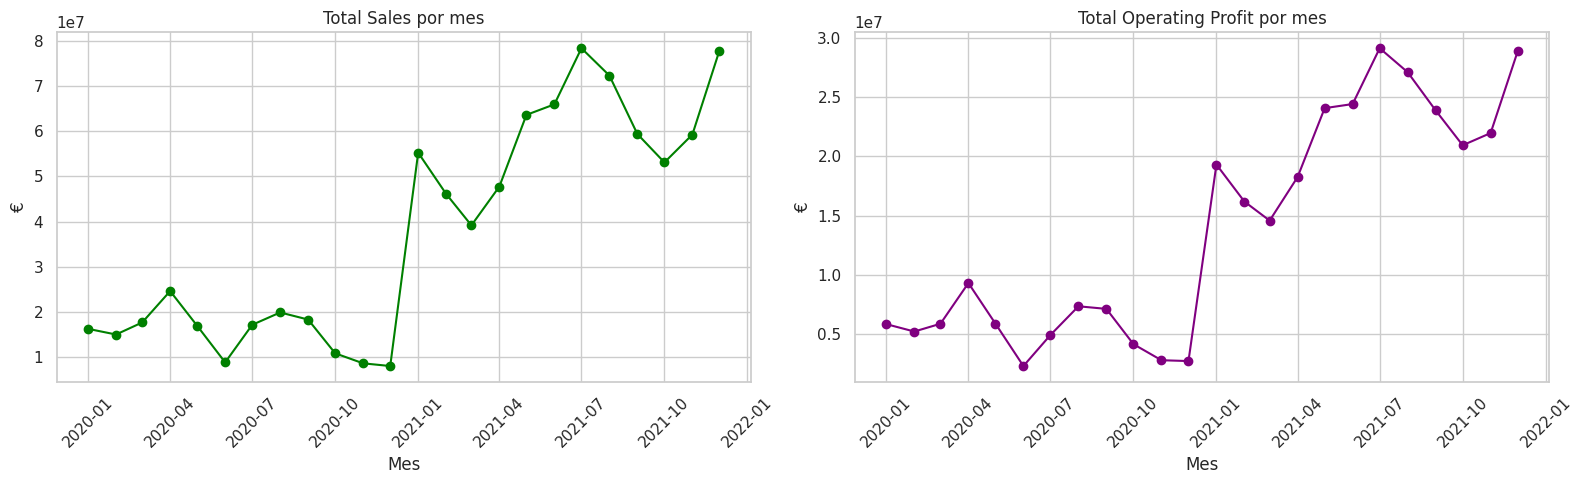

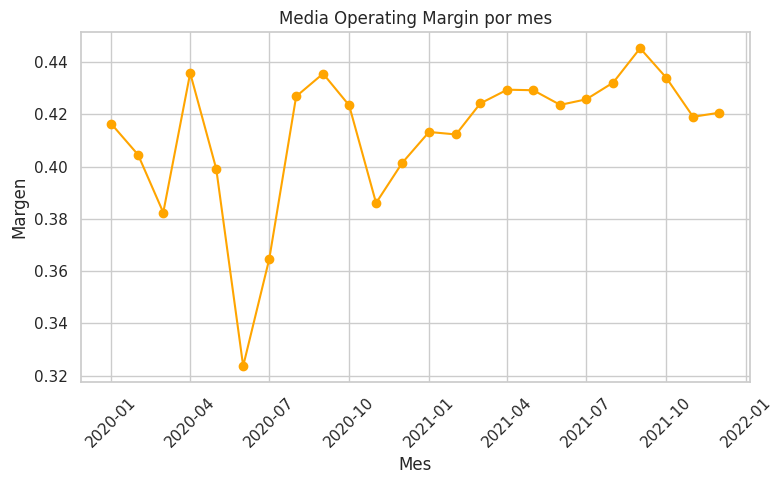

In [34]:
df["Invoice Date"] = pd.to_datetime(df["Invoice Date"], errors='coerce')
df["Month"] = df["Invoice Date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby("Month").agg({
    "Price per Unit": "mean",
    "Units Sold": "sum",
    "Total Sales": "sum",
    "Operating Profit": "sum",
    "Operating Margin": "mean"
}).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly["Month"], monthly["Price per Unit"], marker='o', color='red')
axes[0].set_title("Media Price per Unit por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("€")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly["Month"], monthly["Units Sold"], marker='o', color='blue')
axes[1].set_title("Total Units Sold por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Unidades")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly["Month"], monthly["Total Sales"], marker='o', color='green')
axes[0].set_title("Total Sales por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("€")
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly["Month"], monthly["Operating Profit"], marker='o', color='purple')
axes[1].set_title("Total Operating Profit por mes")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("€")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(monthly["Month"], monthly["Operating Margin"], marker='o', color='orange')
plt.title("Media Operating Margin por mes")
plt.xlabel("Mes")
plt.ylabel("Margen")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Los gráficos evidencian un punto de inflexión muy claro a comienzos de 2021, cuando tanto las ventas, las unidades vendidas como los beneficios se disparan de forma simultánea. Durante 2020 se aprecia un mercado inestable, con caídas prolongadas asociadas probablemente a las restricciones por la pandemia. A partir de enero de 2021 se produce un salto abrupto en las ventas —coincidente con el repunte de unidades— que marca una nueva etapa de crecimiento sostenido. Este cambio refleja una recuperación del consumo y una reactivación del comercio minorista, acompañada de un fuerte impulso del canal online y de los outlets, que ganan relevancia frente a la tienda física.

En términos de rentabilidad, el margen operativo medio se mantiene estable en torno al 40-44 %, mostrando resiliencia incluso en periodos de menor venta. Aunque el precio medio por unidad experimenta caídas puntuales, especialmente a mediados de 2020 y principios de 2021, el volumen compensó esa bajada, impulsando tanto las ventas totales como el beneficio operativo. La tendencia conjunta revela un modelo eficiente de ajuste precio-volumen, donde Adidas logró sostener la rentabilidad y salir reforzada tras la crisis sanitaria, consolidando un crecimiento estable a lo largo de 2021.

## ***Relaciones entre algunas variables***

Veamos ahora relaciones interesantes entre algunas de las variables.

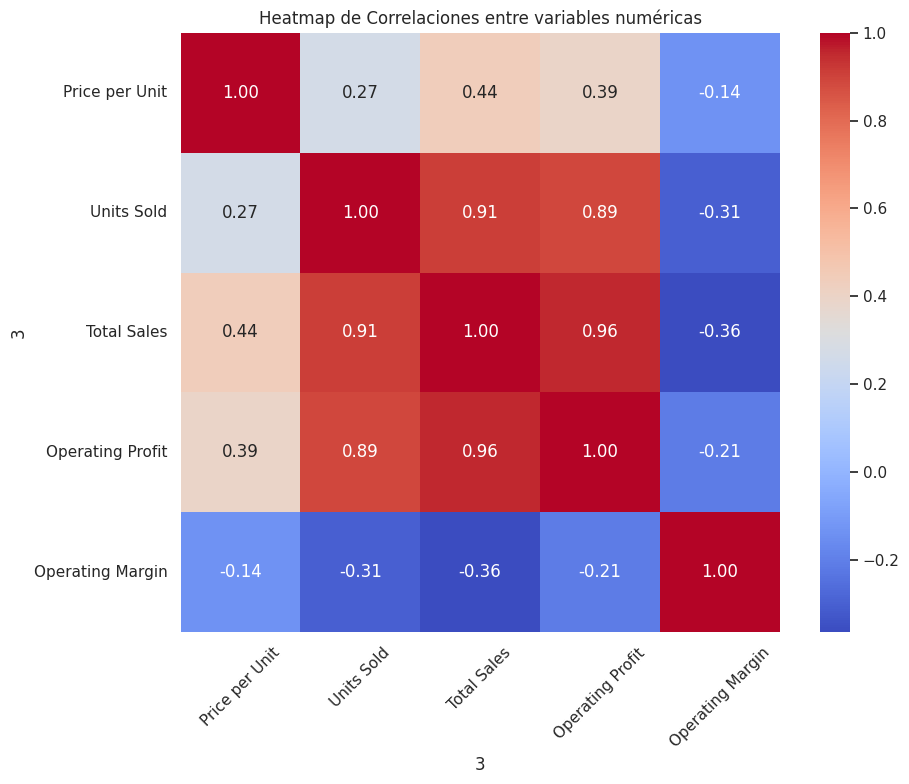

In [37]:
cols = ["Price per Unit", "Units Sold", "Total Sales", "Operating Profit", "Operating Margin"]

# Matriz de correlación
corr = df[cols].corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True,
            xticklabels=cols, yticklabels=cols)

plt.title("Heatmap de Correlaciones entre variables numéricas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El mapa de correlaciones nos revela relaciones muy fuertes entre las variables de volumen y rendimiento: Units Sold, Total Sales y Operating Profit presentan correlaciones superiores al 0.89, lo que indica que el beneficio operativo está fuertemente impulsado por el volumen de ventas. En cambio, Price per Unit muestra solo una correlación moderada con las ventas totales (0.44) y baja con las unidades vendidas (0.27), sugiriendo que el precio influye menos en el desempeño global que la cantidad comercializada. Por otro lado, el “Operating Margin” tiene correlaciones negativas con todas las variables de escala, destacando una tendencia a la compresión de márgenes cuando aumenta el volumen o las ventas totales, un patrón típico en estrategias basadas en rotación y descuentos. En conjunto, el gráfico refleja un modelo de crecimiento basado en volumen más que en precio, donde la eficiencia operativa es clave para mantener la rentabilidad.

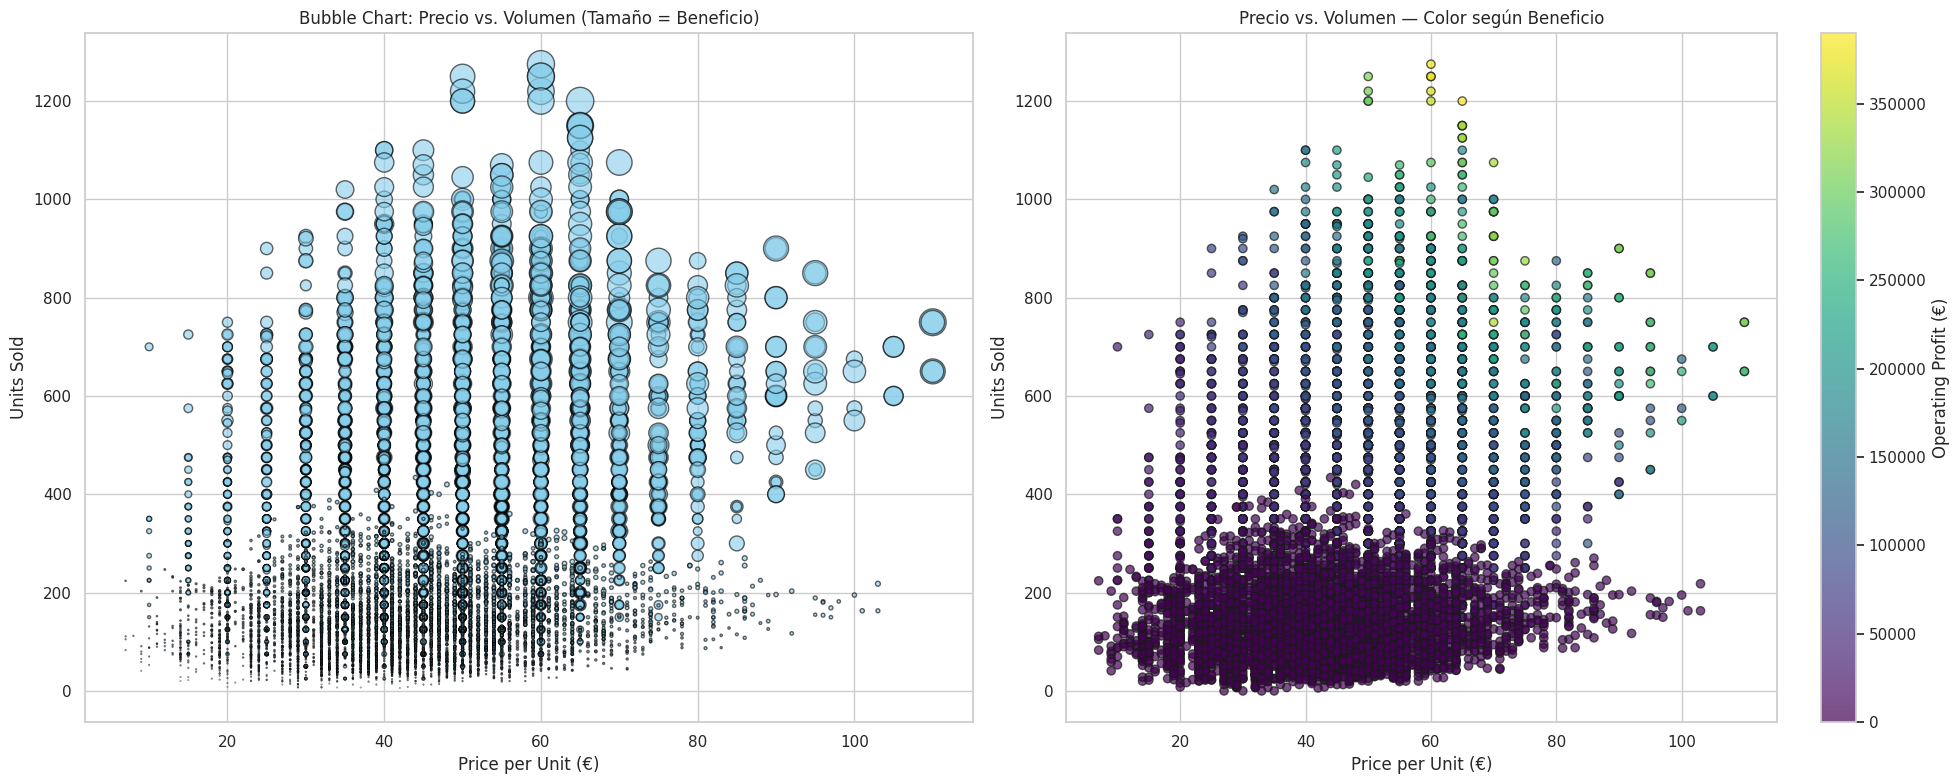

In [40]:
size = df["Operating Profit"]* 0.001
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Bubble chart: tamaño = beneficio
axes[0].scatter(
    df["Price per Unit"],
    df["Units Sold"],
    s=size,
    alpha=0.6,
    c="skyblue",
    edgecolor="black"
)
axes[0].set_xlabel("Price per Unit (€)")
axes[0].set_ylabel("Units Sold")
axes[0].set_title("Bubble Chart: Precio vs. Volumen (Tamaño = Beneficio)")
axes[0].grid(True)

# Scatter plot: color = beneficio
scatter = axes[1].scatter(
    df["Price per Unit"],
    df["Units Sold"],
    c=df["Operating Profit"],
    cmap="viridis",
    alpha=0.7,
    edgecolor="k"
)
fig.colorbar(scatter, ax=axes[1], label="Operating Profit (€)")
axes[1].set_xlabel("Price per Unit (€)")
axes[1].set_ylabel("Units Sold")
axes[1].set_title("Precio vs. Volumen — Color según Beneficio")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Los gráficos de dispersión nos permiten visualizar la relación entre el precio unitario, el volumen de ventas y el beneficio operativo. Se observa que los puntos con mayores beneficios (burbujas grandes o colores más intensos) se concentran principalmente en un rango de precios entre 40 € y 70 €, lo que indica que ese intervalo representa un equilibrio óptimo entre margen y demanda. A precios más bajos, las ventas son frecuentes pero con beneficios reducidos, mientras que a precios muy altos el volumen de ventas disminuye drásticamente. En conjunto, los gráficos sugieren una curva de rentabilidad tipo “campana”, donde los beneficios máximos se alcanzan en un punto medio de precio, típico de estrategias de pricing basado en valor percibido más que en volumen o lujo extremo. Además, el aumento de beneficios en zonas de alto volumen confirma que la eficiencia operativa escala positivamente con la demanda, consolidando un modelo de crecimiento rentable pero sensible al precio.

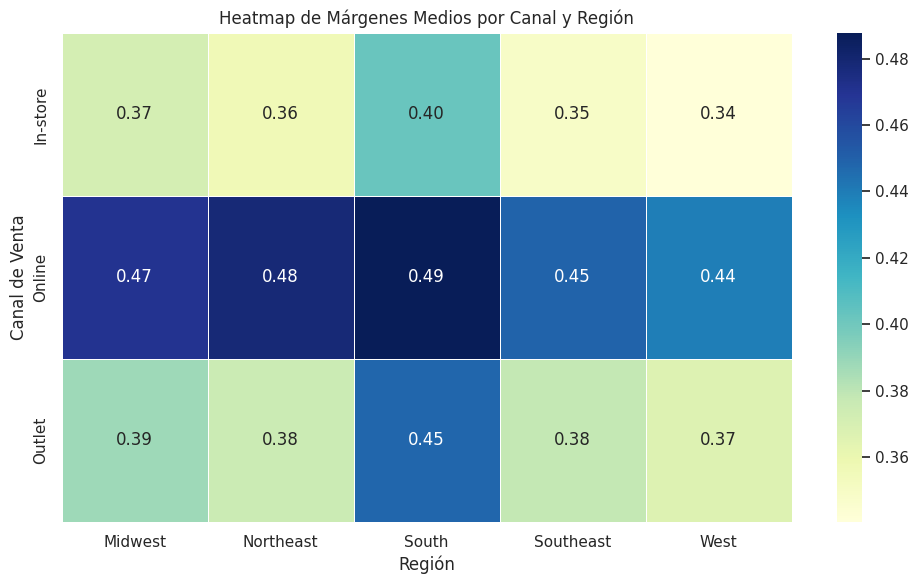

In [41]:
pivot_table = df.pivot_table(
    values="Operating Margin",
    index="Sales Method",
    columns="Region",
    aggfunc="mean"
)

# Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5)

plt.title("Heatmap de Márgenes Medios por Canal y Región")
plt.xlabel("Región")
plt.ylabel("Canal de Venta")
plt.tight_layout()
plt.show()

El heatmap de márgenes medios revela una distribución desigual de la rentabilidad entre regiones y canales. El canal Online destaca como el más rentable en todas las zonas, con márgenes que oscilan entre 0.44 y 0.49, reflejando una estructura de costes más eficiente y posiblemente una menor dependencia de gastos fijos asociados a tiendas físicas. En cambio, el canal In-store presenta los márgenes más bajos (0.34-0.40), lo que sugiere un impacto mayor de costes operativos y de personal. El canal Outlet se sitúa en una posición intermedia, con un rendimiento sólido en el South (0.45) que podría deberse a estrategias de liquidación más efectivas o a un volumen de ventas sostenido. Regionalmente, el South y el Northeast se perfilan como las áreas más rentables en promedio, lo que indica un mercado más maduro o con mejor alineación entre precio y demanda. En conjunto, el gráfico apunta a que la digitalización y la optimización regional son factores clave para sostener y ampliar los márgenes.

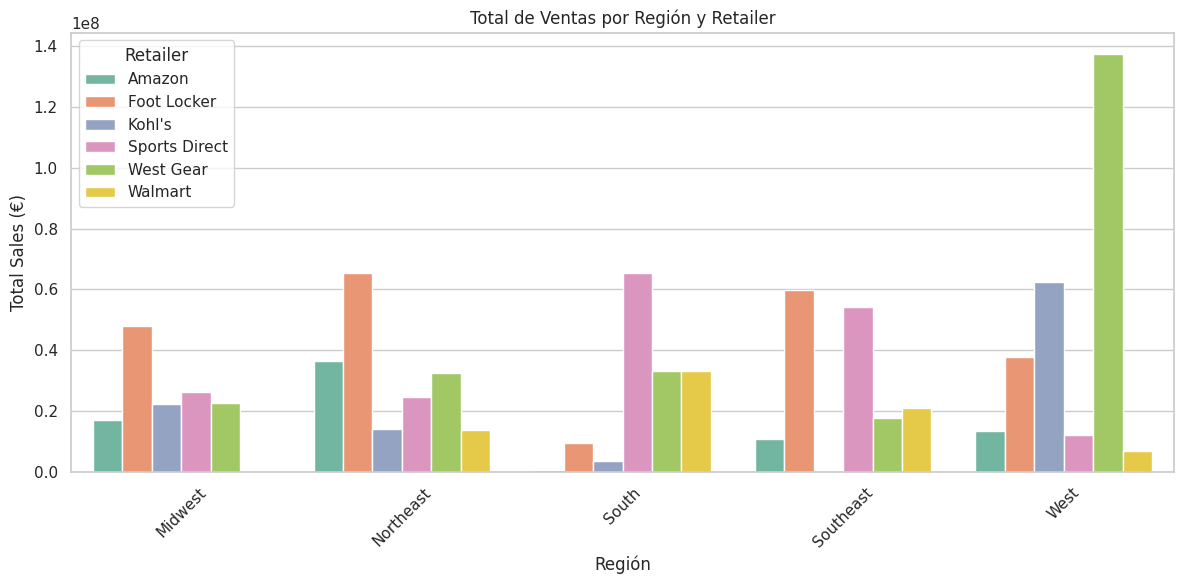

In [42]:
grouped = df.groupby(["Region", "Retailer"])["Total Sales"].sum().reset_index()

sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

sns.barplot(data=grouped, x="Region", y="Total Sales", hue="Retailer", palette="Set2")
plt.title("Total de Ventas por Región y Retailer")
plt.xlabel("Región")
plt.ylabel("Total Sales (€)")
plt.xticks(rotation=45)
plt.legend(title="Retailer")
plt.tight_layout()
plt.show()

El gráfico de ventas por región y retailer evidencia una alta heterogeneidad geográfica en el rendimiento de los distribuidores. West Gear domina claramente en la región West, superando con creces al resto con más de 130 millones de euros en ventas, lo que sugiere una fuerte presencia o especialización logística en esa zona. Foot Locker lidera en la mayoría de las demás regiones, con picos notables en el Northeast y Southeast, lo que podría reflejar su posición consolidada en mercados urbanos. Sports Direct destaca en el South y Southeast, posiblemente aprovechando una mayor afinidad con productos deportivos y campañas de outlet. Amazon mantiene un rendimiento estable en todas las regiones, aunque sin alcanzar cifras dominantes, mientras que Kohl’s y Walmart muestran comportamientos más localizados, destacando en el West y South, respectivamente. En conjunto, la distribución sugiere que las estrategias de los retailers están fuertemente condicionadas por la geografía, con zonas de concentración que podrían guiar decisiones de expansión o reposicionamiento de marca.

/tmp/ipython-input-390765840.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=sales_by_daytype, x="Weekend", y="Total Sales", palette="pastel", ax=axes[0])


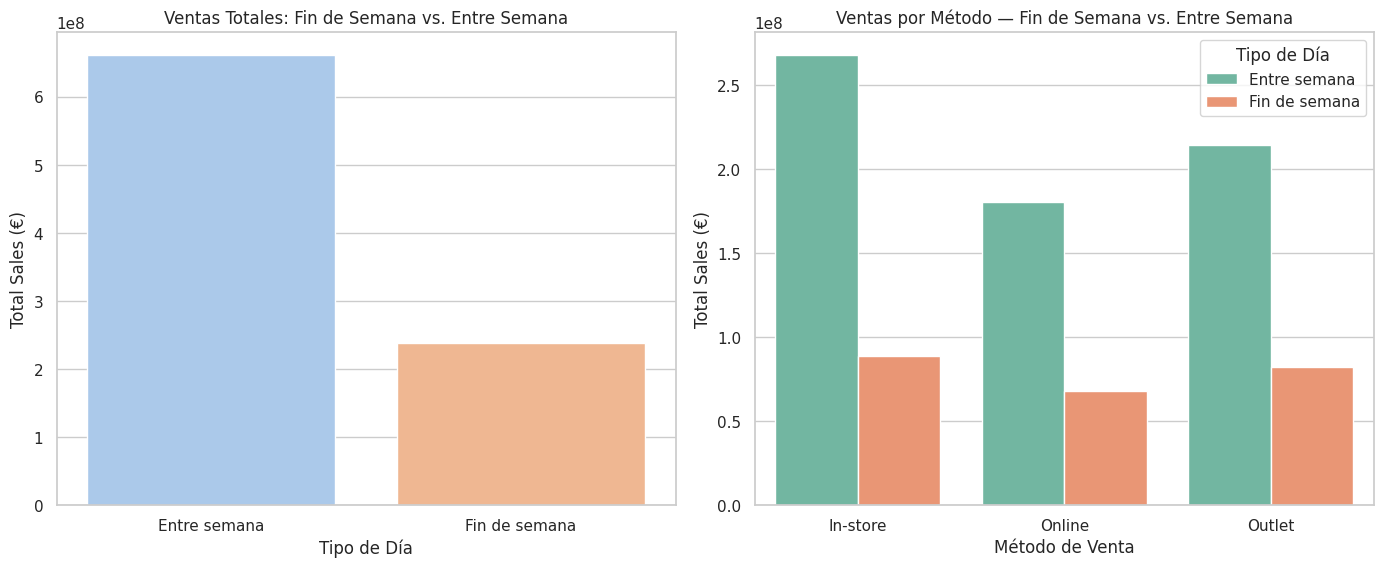

In [47]:
df["Weekend"] = df["Invoice Date"].dt.dayofweek >= 5  # Sábado (5) o Domingo (6)
df["Weekend"] = df["Weekend"].map({True: "Fin de semana", False: "Entre semana"})

sales_by_daytype = df.groupby("Weekend")["Total Sales"].sum().reset_index()
sales_by_method_day = df.groupby(["Sales Method", "Weekend"])["Total Sales"].sum().reset_index()

sns.set(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total ventas por tipo de día
sns.barplot(data=sales_by_daytype, x="Weekend", y="Total Sales", palette="pastel", ax=axes[0])
axes[0].set_title("Ventas Totales: Fin de Semana vs. Entre Semana")
axes[0].set_xlabel("Tipo de Día")
axes[0].set_ylabel("Total Sales (€)")

# Ventas por método, agrupado por tipo de día
sns.barplot(data=sales_by_method_day, x="Sales Method", y="Total Sales", hue="Weekend", palette="Set2", ax=axes[1])
axes[1].set_title("Ventas por Método — Fin de Semana vs. Entre Semana")
axes[1].set_xlabel("Método de Venta")
axes[1].set_ylabel("Total Sales (€)")
axes[1].legend(title="Tipo de Día")

plt.tight_layout()
plt.show()

Los gráficos comparan las ventas totales entre días laborables y fines de semana, revelando un patrón claro de mayor actividad comercial entre semana, donde las ventas casi triplican las del fin de semana. Este comportamiento sugiere que la mayor parte del consumo se concentra durante los días hábiles, posiblemente impulsado por compras planificadas, compras corporativas o mayor tráfico en tiendas regulares.

Al segmentar por canal, observamos que In-store mantiene el liderazgo en ambos periodos, aunque el descenso durante los fines de semana es notable. Online y Outlet siguen una tendencia similar, pero con caídas menos pronunciadas, lo que indica una mayor estabilidad del canal digital frente a la estacionalidad de los hábitos presenciales. En conjunto, los datos sugieren que las campañas de marketing o promociones de fin de semana podrían ser una oportunidad estratégica para equilibrar la distribución temporal de las ventas y aumentar la conversión en momentos de menor actividad.

# ***IMPLEMENTACIÓN DE MACHINE LEARNING***

En esta sección desarrollamos la fase de Machine Learning, cuyo objetivo es construir un modelo predictivo capaz de estimar el número de unidades vendidas  a partir de las variables explicativas más relevantes del conjunto de datos de Adidas.
Tras el análisis exploratorio, hemos seleccionado únicamente aquellas variables independientes que no implican fuga de información, como el precio por unidad, región, producto, retailer, canal de venta y fecha (mes y año), excluyendo las variables derivadas de las propias ventas (Total Sales, Operating Profit y Operating Margin).

Aplicaremos diferentes modelos en búsqueda del que mejor prediga y más robusto sea.

In [52]:
df_ml = df.copy()
df_ml["Invoice Date"] = pd.to_datetime(df_ml["Invoice Date"], errors="coerce")
df_ml["Month"] = df_ml["Invoice Date"].dt.month
df_ml["Year"] = df_ml["Invoice Date"].dt.year

vars = ["Price per Unit", "Region", "Product", "Retailer", "Sales Method", "Month", "Year"]
obj = "Units Sold"

df_encoded = pd.get_dummies(df_ml[vars], drop_first=True)
X = df_encoded
y = df_ml[obj].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

***Regresión lineal***

Empezaremos por los modelos más básicos, regresión lineal y algunas de sus variantes como Ridge o Lasso.

In [54]:
reg_leg = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

reg_leg.fit(X_train, y_train)
y_reg_leg = reg_leg.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, y_reg_leg))
mae = mean_absolute_error(y_test, y_reg_leg)
r2 = r2_score(y_test, y_reg_leg)

print(f"RMSE (RL): {rmse:.2f}")
print(f"MAE (RL): {mae:.2f}")
print(f"R² (RL): {r2:.2f}")

RMSE (RL): 170.24
MAE (RL): 124.27
R² (RL): 0.39


In [55]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Ridge())
])

ridge.fit(X_train, y_train)
y_ridge = ridge.predict(X_test)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_ridge))
mae_ridge = mean_absolute_error(y_test, y_ridge)
r2_ridge = r2_score(y_test, y_ridge)

print(f"RMSE (Ridge): {rmse_ridge:.2f}")
print(f"MAE (Ridge): {mae_ridge:.2f}")
print(f"R² (Ridge): {r2_ridge:.2f}")

RMSE (Ridge): 170.24
MAE (Ridge): 124.27
R² (Ridge): 0.39


In [56]:
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", Lasso())
])

lasso.fit(X_train, y_train)
y_lasso = lasso.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_lasso))
mae_lasso = mean_absolute_error(y_test, y_lasso)
r2_lasso = r2_score(y_test, y_lasso)

print(f"RMSE (Lasso): {rmse_lasso:.2f}")
print(f"MAE (Lasso): {mae_lasso:.2f}")
print(f"R² (Lasso): {r2_lasso:.2f}")

RMSE (Lasso): 170.59
MAE (Lasso): 124.32
R² (Lasso): 0.38


Los tres modelos lineales presentan resultados prácticamente idénticos, con un R² en torno a 0.39 y errores medios similares (RMSE ≈ 170 y MAE ≈ 124).
Esto indica que los modelos logran explicar alrededor del 39 % de la variabilidad en las unidades vendidas, lo cual es un punto de partida razonable, pero evidencia que las relaciones entre las variables del dataset no son puramente lineales.

El hecho de que Ridge y Lasso no mejoren significativamente el desempeño nos sugiere que no existe una colinealidad fuerte ni un sobreajuste severo en los coeficientes del modelo base, por lo que la limitación no está en la regularización, sino en la capacidad de los modelos lineales para capturar interacciones complejas entre variables como producto, canal, región o precio.
Estos resultados justifican la necesidad de pasar a modelos no lineales, como árboles de decisión, Random Forest o XGBoost, que permitan modelar comportamientos más realistas del mercado.

### ***Árboles de decisión***

In [57]:
tree = DecisionTreeRegressor()
tree.fit(X_train, y_train)

y_tree = tree.predict(X_test)

rmse_tree = np.sqrt(mean_squared_error(y_test, y_tree))
mae_tree = mean_absolute_error(y_test, y_tree)
r2_tree = r2_score(y_test, y_tree)

print(f"RMSE (Tree): {rmse_tree:.2f}")
print(f"MAE (Tree): {mae_tree:.2f}")
print(f"R² (Tree): {r2_tree:.2f}")

RMSE (Tree): 129.17
MAE (Tree): 73.54
R² (Tree): 0.65


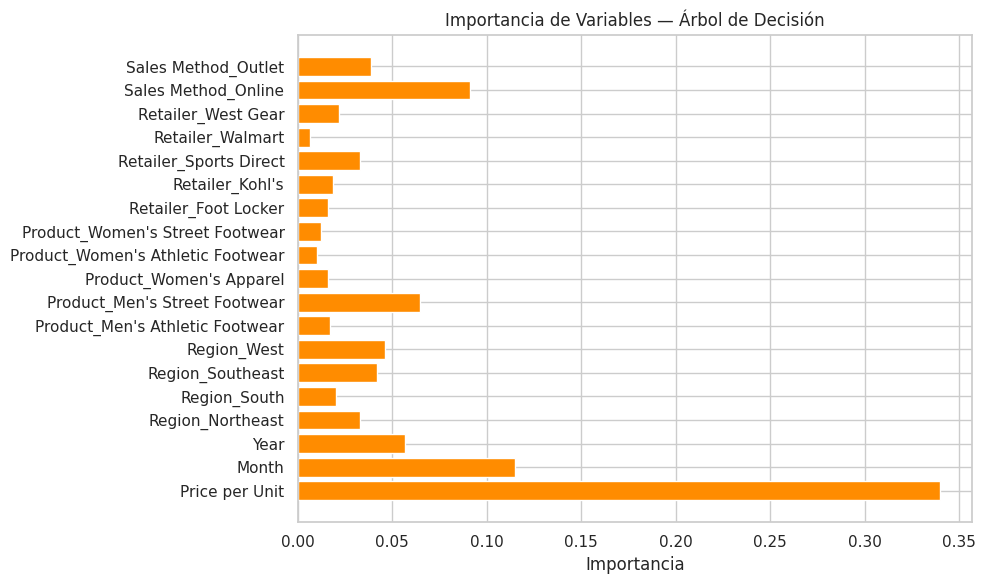

In [61]:
importancia_tree = tree.feature_importances_
vars = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(vars, importancia_tree, color="darkorange")
plt.xlabel("Importancia")
plt.title("Importancia de Variables — Árbol de Decisión")
plt.tight_layout()
plt.show()

In [58]:
tree_model = DecisionTreeRegressor()

param_grid = {
    "max_depth": [4, 8, 12, 16, 20, 23, 25, 30, 35, 40],
    "min_samples_split": [2, 3, 4,5, 6, 10, 12,15, 20],
    "min_samples_leaf": [2,3,4, 5, 7, 10]
}

grid_search = GridSearchCV(
    estimator=tree_model,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
y_best_tree = best_tree.predict(X_test)


rmse_best_tree = np.sqrt(mean_squared_error(y_test, y_best_tree))
mae_best_tree = mean_absolute_error(y_test, y_best_tree)
r2_best_tree = r2_score(y_test, y_best_tree)

print("Mejor Árbol de Decisión:")
print(f"Parámetros: {grid_search.best_params_}")
print(f"RMSE (best tree): {rmse_best_tree:.2f}")
print(f"MAE (best tree): {mae_best_tree:.2f}")
print(f"R² (best tree): {r2_best_tree:.2f}")

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Mejor Árbol de Decisión:
Parámetros: {'max_depth': 40, 'min_samples_leaf': 3, 'min_samples_split': 4}
RMSE (best tree): 118.96
MAE (best tree): 71.95
R² (best tree): 0.70


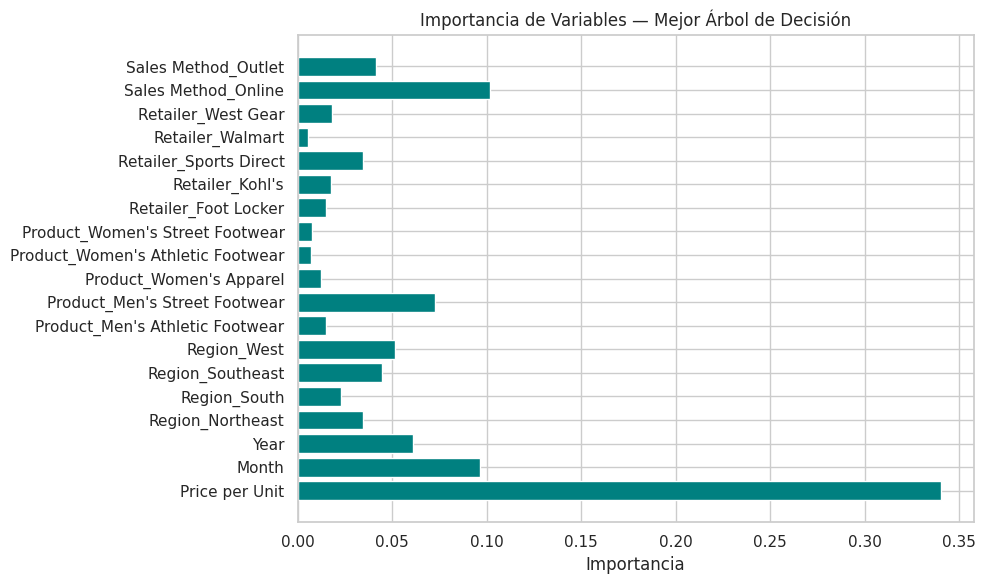

In [62]:
importancia_best_tree = best_tree.feature_importances_
vars = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(vars, importancia_best_tree, color="teal")
plt.xlabel("Importancia")
plt.title("Importancia de Variables — Mejor Árbol de Decisión")
plt.tight_layout()
plt.show()

El modelo de árbol de decisión presenta una mejora notable respecto a los modelos lineales, alcanzando un R² de 0.65 en su versión inicial y 0.70 tras la optimización de hiperparámetros, lo que significa que ahora explica el 70 % de la variabilidad en las ventas. Además, los errores disminuyen considerablemente (RMSE pasa de 170 a 119 y MAE de 124 a 72), reflejando una predicción mucho más precisa.

Los mejores resultados los obtuvimos con una estructura relativamente profunda (max_depth = 40) y umbrales de división ajustados (min_samples_split = 4, min_samples_leaf = 3), lo que permite al modelo capturar relaciones más complejas entre variables como precio, región, canal o producto sin llegar a sobreajustar.
En conjunto, estos valores confirman que la no linealidad del comportamiento de las ventas es un factor clave y que los árboles de decisión ofrecen una representación más realista y eficaz de los patrones comerciales presentes en el dataset.

El análisis de importancia de variables nos confirma que el factor con mayor peso en las predicciones del modelo es el precio por unidad, lo que demuestra su fuerte influencia sobre el volumen de ventas. Le siguen en relevancia las variables mes y canal de venta online, evidenciando una marcada estacionalidad y la creciente importancia del comercio digital en el rendimiento global de Adidas. También destacan las regiones West y Southeast, así como algunos productos específicos como el Men's Street Footwear, lo que refleja diferencias de comportamiento entre zonas y líneas de producto.

En el modelo optimizado, la jerarquía de variables se mantiene estable, aunque se observa una mayor concentración del peso en las variables clave (precio y canal), indicando que el ajuste de hiperparámetros ha permitido al modelo enfocarse mejor en los factores verdaderamente determinantes de la demanda. En conjunto, estos resultados confirman la consistencia del árbol de decisión y ofrecen información valiosa para orientar futuras estrategias de precios, distribución y marketing.

### ***Random forest***

In [59]:
forest = RandomForestRegressor()
forest.fit(X_train, y_train)

y_forest = forest.predict(X_test)

rmse_forest = np.sqrt(mean_squared_error(y_test, y_forest))
mae_forest = mean_absolute_error(y_test, y_forest)
r2_forest = r2_score(y_test, y_forest)

print(f"RMSE (Forest): {rmse_forest:.2f}")
print(f"MAE (Forest): {mae_forest:.2f}")
print(f"R² (Forest): {r2_forest:.2f}")

RMSE (Forest): 101.91
MAE (Forest): 64.00
R² (Forest): 0.78


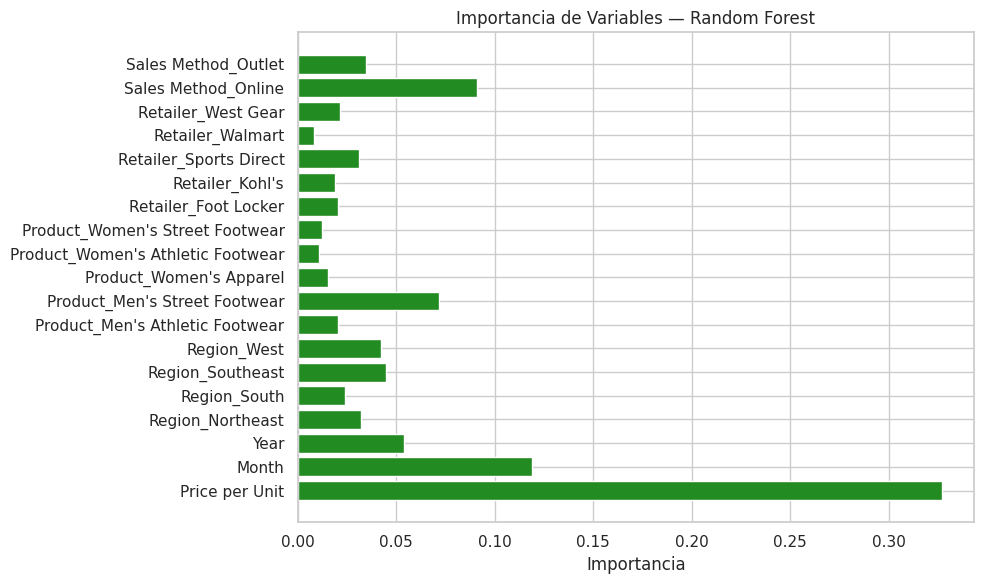

In [63]:
importancia_forest = forest.feature_importances_
vars = X_train.columns

plt.figure(figsize=(10, 6))
plt.barh(vars, importancia_forest, color="forestgreen")
plt.xlabel("Importancia")
plt.title("Importancia de Variables — Random Forest")
plt.tight_layout()
plt.show()

El modelo de Random Forest alcanza un R² de 0.78, con un RMSE de 101.91 y un MAE de 64.00, lo que representa una mejora significativa respecto al árbol de decisión y los modelos lineales. Este rendimiento indica que el modelo explica aproximadamente el 78 % de la variabilidad en las unidades vendidas, con errores de predicción moderados y buena capacidad de generalización.

En cuanto a la importancia de las variables, destaca nuevamente el precio por unidad como el factor más determinante en las ventas, seguido por la estacionalidad, el canal online y algunas regiones específicas como West y Southeast. Estos resultados refuerzan la idea de que las ventas de Adidas están fuertemente condicionadas por la estrategia de precios, la temporalidad y el comportamiento del consumidor en cada canal y zona geográfica.

### ***XGBoost***

In [65]:
xgb = XGBRegressor()
xgb.fit(X_train, y_train)

y_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_xgb))
mae_xgb = mean_absolute_error(y_test, y_xgb)
r2_xgb = r2_score(y_test, y_xgb)

print(f"RMSE (XGBoost): {rmse_xgb:.2f}")
print(f"MAE (XGBoost): {mae_xgb:.2f}")
print(f"R² (XGBoost): {r2_xgb:.2f}")

RMSE (XGBoost): 90.99
MAE (XGBoost): 59.69
R² (XGBoost): 0.82


<Figure size 1000x600 with 0 Axes>

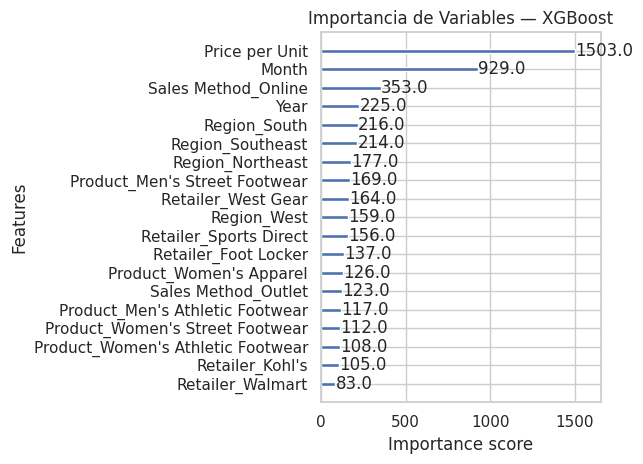

In [66]:
plt.figure(figsize=(10, 6))
plot_importance(xgb, importance_type="weight", max_num_features=20)
plt.title("Importancia de Variables — XGBoost")
plt.tight_layout()
plt.show()

In [68]:
xgb_model = XGBRegressor()

param_dist = {
    "n_estimators": [100, 300, 500, 700, 1000],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.22, 0.3],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.5, 0.75, 1],
    "gamma": [0, 1, 3, 5]
}

best_xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    verbose=2,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

best_xgb_search.fit(X_train, y_train)

best_xgb = best_xgb_search.best_estimator_
y_best_xgb = best_xgb.predict(X_test)

rmse_best_xgb = np.sqrt(mean_squared_error(y_test, y_best_xgb))
mae_best_xgb = mean_absolute_error(y_test, y_best_xgb)
r2_best_xgb = r2_score(y_test, y_best_xgb)

print("Mejor XGBoost (RandomizedSearchCV):")
print(f"Parámetros: {best_xgb_search.best_params_}")
print(f"RMSE (best_xgb): {rmse_best_xgb:.2f}")
print(f"MAE (best_xgb): {mae_best_xgb:.2f}")
print(f"R² (best_xgb): {r2_best_xgb:.2f}")
print(f"Error medio relativo (best_xgb): {mae_best_xgb/(max(df["Units Sold"])-min(df["Units Sold"])):.2f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejor XGBoost (RandomizedSearchCV):
Parámetros: {'subsample': 0.5, 'n_estimators': 700, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 3}
RMSE (best_xgb): 89.64
MAE (best_xgb): 57.63
R² (best_xgb): 0.83
Error medio relativo (best_xgb): 0.05


<Figure size 1000x600 with 0 Axes>

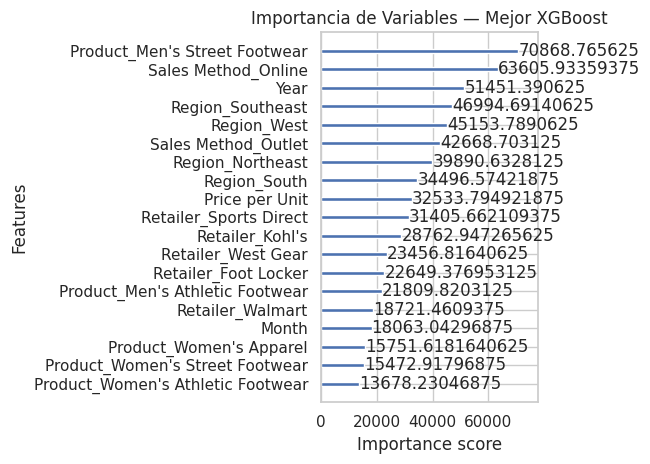

In [70]:
plt.figure(figsize=(10, 6))
plot_importance(best_xgb, importance_type="gain", max_num_features=20)
plt.title("Importancia de Variables — Mejor XGBoost")
plt.tight_layout()
plt.show()

El modelo de XGBoost logra el mejor rendimiento global de todos los algoritmos aplicados, alcanzando un R² de 0.83, con un RMSE de 89.64 y un MAE de 57.63, lo que implica un error medio relativo del 5 % sobre el rango total de unidades vendidas. Esto confirma una excelente capacidad predictiva y generalización del modelo, que consigue capturar la complejidad de las relaciones entre las variables de forma más eficiente que los modelos anteriores.

En cuanto a la importancia de las variables, el precio por unidad y el mes se consolidan nuevamente como los factores más influyentes en las predicciones, seguidos por el canal online y las regiones geográficas, especialmente South, Southeast y West. El modelo optimizado muestra una distribución más equilibrada del peso entre variables, destacando además el papel del producto Men's Street Footwear y el año, lo que sugiere una mayor sensibilidad del modelo ante la evolución temporal y las características específicas de los productos.

En conjunto, el XGBoost combina alta precisión, estabilidad y robustez frente al sobreajuste, convirtiéndose en el modelo más adecuado para utilizarse como función de demanda en el posterior proceso de optimización de precios.

### ***Resumen***

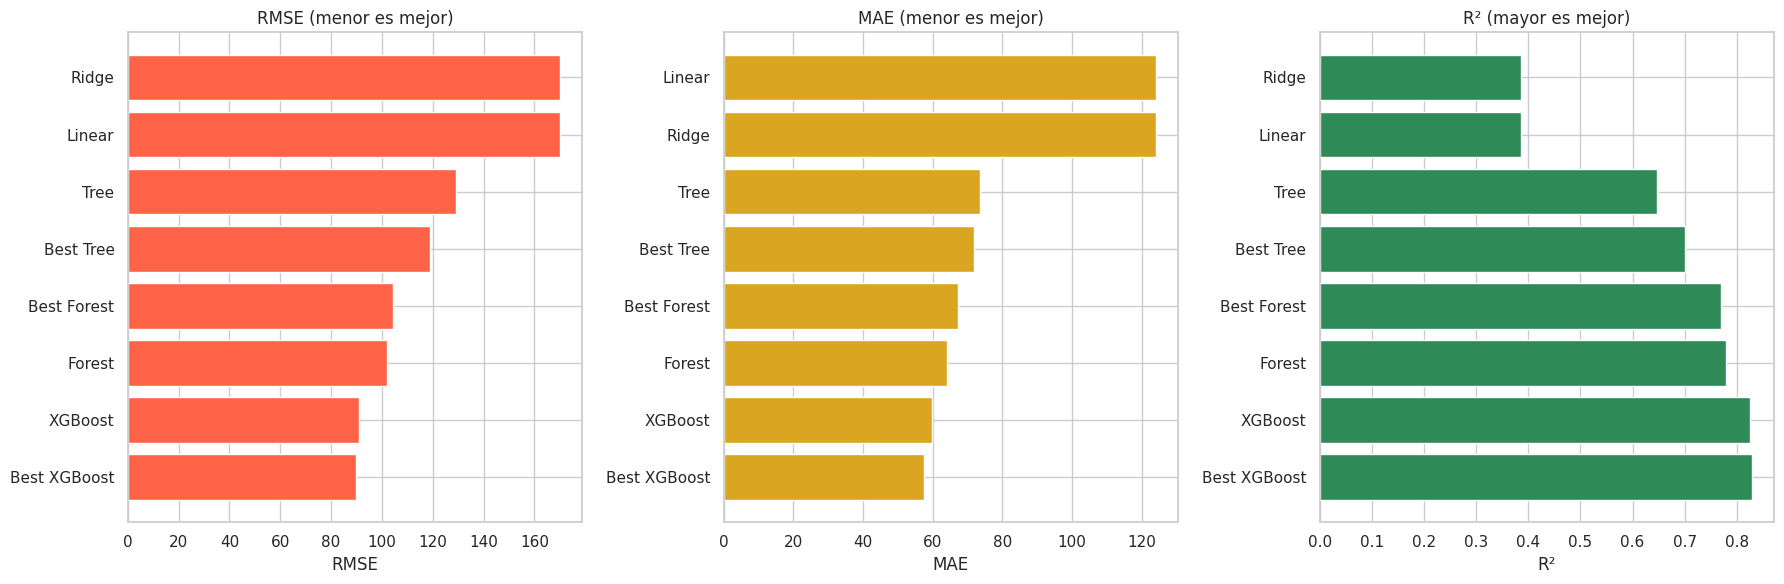

In [72]:
metricas = {
    "Tree": [rmse_tree, mae_tree, r2_tree],
    "Best Tree": [rmse_best_tree, mae_best_tree, r2_best_tree],
    "Forest": [rmse_forest, mae_forest, r2_forest],
    "Best Forest": [rmse_best_forest, mae_best_forest, r2_best_forest],
    "XGBoost": [rmse_xgb, mae_xgb, r2_xgb],
    "Best XGBoost": [rmse_best_xgb, mae_best_xgb, r2_best_xgb],
    "Linear": [rmse, mae, r2],
    "Ridge": [rmse_ridge, mae_ridge, r2_ridge]
}
df_metrics = pd.DataFrame(metricas, index=["RMSE", "MAE", "R²"]).T

df_rmse = df_metrics.sort_values("RMSE")
df_mae = df_metrics.sort_values("MAE")
df_r2 = df_metrics.sort_values("R²", ascending=False)


fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].barh(df_rmse.index, df_rmse["RMSE"], color="tomato")
axes[0].set_title("RMSE (menor es mejor)")
axes[0].set_xlabel("RMSE")

axes[1].barh(df_mae.index, df_mae["MAE"], color="goldenrod")
axes[1].set_title("MAE (menor es mejor)")
axes[1].set_xlabel("MAE")

axes[2].barh(df_r2.index, df_r2["R²"], color="seagreen")
axes[2].set_title("R² (mayor es mejor)")
axes[2].set_xlabel("R²")

# Ajustar diseño
plt.tight_layout()
plt.show()

El conjunto de modelos aplicados muestra una progresión clara en la capacidad predictiva conforme se avanza desde algoritmos lineales hacia métodos no lineales y conjuntos.
Mientras los modelos Lineal, Ridge y Lasso ofrecen un rendimiento limitado (R² ≈ 0.39), los árboles de decisión y, especialmente, los modelos conjuntos (Random Forest y XGBoost) logran mejoras sustanciales tanto en precisión como en estabilidad.

El XGBoost se consolida como el modelo más preciso y robusto, alcanzando un R² de 0.83, un RMSE de 89.6 y un MAE de 57.6, con un error medio relativo del 5 % sobre el rango de ventas.
Su arquitectura basada en 'gradient boosting' permite capturar relaciones no lineales y complejas entre las variables como interacciones entre producto, región, canal de venta y precio sin incurrir en sobreajuste, gracias a sus mecanismos internos de regularización.

Desde un punto de vista de negocio, este rendimiento convierte al modelo en una herramienta altamente fiable para la predicción de ventas, ya que combina alta precisión, interpretabilidad y escalabilidad.
El modelo puede emplearse para anticipar la demanda bajo diferentes escenarios de precio o distribución, optimizar inventarios y servir como base para estrategias de pricing dinámico, haciendo de XGBoost una solución idónea para la toma de decisiones basada en datos dentro del contexto comercial de Adidas.

# ***OPTIMIZACIÓN***

En esta sección aplicaremos el modelo XGBoost al ámbito del pricing predictivo, con el objetivo de estimar el precio futuro de un producto determinado en función de su comportamiento histórico y de las variables contextuales del mercado.
Para ello, se ha tomado como ejemplo el producto “Men's Street Footwear”, utilizando información temporal, junto con factores como el canal de venta, la región y el distribuidor. El propósito es analizar la evolución de los precios y anticipar su valor esperado para el próximo periodo, permitiendo así obtener una referencia inicial para la toma de decisiones de fijación de precios.

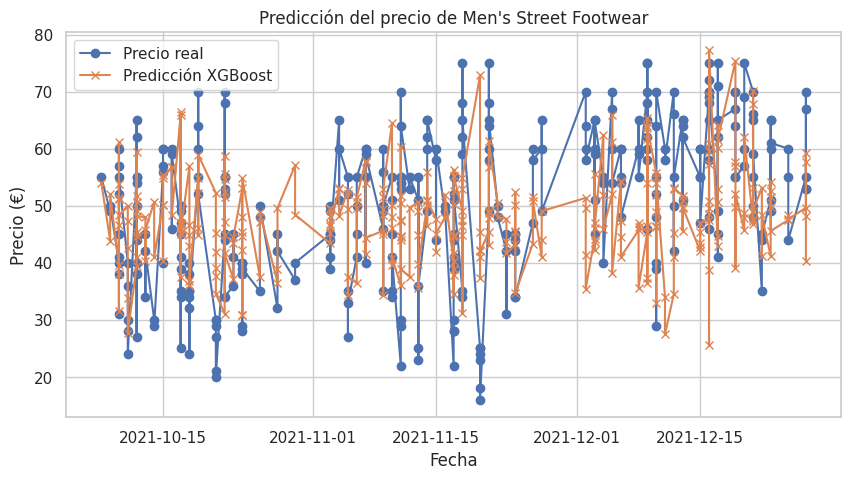

Precio predicho para Men's Street Footwear en el próximo mes: 45.29 €


In [89]:
product_name = "Men's Street Footwear"

df_product = df[df["Product"] == product_name].copy()
df_product["Invoice Date"] = pd.to_datetime(df_product["Invoice Date"], errors="coerce")
df_product = df_product.sort_values("Invoice Date")

df_product["Year"] = df_product["Invoice Date"].dt.year
df_product["Month"] = df_product["Invoice Date"].dt.month
df_product["Quarter"] = df_product["Invoice Date"].dt.to_period("Q").astype(str)

df_product["Lag_1"] = df_product["Price per Unit"].shift(1)
df_product["Lag_2"] = df_product["Price per Unit"].shift(2)

df_product = df_product.dropna(subset=["Lag_1", "Lag_2"])

vars = ["Month", "Year", "Lag_1", "Lag_2", "Region", "Sales Method", "Retailer"]

df_encoded = pd.get_dummies(df_product[vars], drop_first=True)
obj = df_product["Price per Unit"]
X_train, X_test, y_train, y_test = train_test_split(df_encoded, obj, test_size=0.2, shuffle=False)

model_price = XGBRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6, gamma=2, subsample=0.8, random_state=42
)
model_price.fit(X_train, y_train)

y_pred = model_price.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(df_product["Invoice Date"].iloc[-len(y_test):], y_test, label="Precio real", marker='o')
plt.plot(df_product["Invoice Date"].iloc[-len(y_test):], y_pred, label="Predicción XGBoost", marker='x')
plt.title(f"Predicción del precio de {product_name}")
plt.xlabel("Fecha")
plt.ylabel("Precio (€)")
plt.legend()
plt.grid(True)
plt.show()

last_row = df_product.iloc[-1:].copy()
last_row["Month"] = (last_row["Month"] % 12) + 1
if last_row["Month"].iloc[0] == 1:
    last_row["Year"] += 1

last_row["Lag_1"] = df_product["Price per Unit"].iloc[-1]
last_row["Lag_2"] = df_product["Price per Unit"].iloc[-2]

last_encoded = pd.get_dummies(last_row[features], drop_first=True).reindex(columns=df_encoded.columns, fill_value=0)
pred_next = model_price.predict(last_encoded)[0]

print(f"Precio predicho para {product_name} en el próximo mes: {pred_next:.2f} €")

El modelo muestra una capacidad razonable para seguir la tendencia general de los precios, aunque con cierta dispersión debida a la alta variabilidad y a factores exógenos no incluidos en el dataset, como promociones o ajustes estratégicos de la marca.
La predicción para el próximo mes sitúa el precio estimado en torno a 45,29 €, valor coherente con el rango observado históricamente.
Si bien el objetivo principal no es predecir exactamente el precio fijado por Adidas, este ejercicio demuestra la capacidad del modelo para capturar patrones temporales y estacionales, ofreciendo una base sólida para su integración en procesos posteriores de optimización de precios, donde se buscará calcular el precio que maximice el beneficio esperado o identificar momentos óptimos para aplicar descuentos u ofertas promocionales que incrementen la rentabilidad global.

# ***Conclusiones***

El análisis integral de ventas de Adidas en Estados Unidos nos ha permitido extraer una visión profunda del comportamiento comercial de la marca, combinando un estudio exploratorio detallado con técnicas avanzadas de aprendizaje automático y optimización.

A través del EDA conseguimos evidenciar la fuerte influencia de factores como el canal de venta, la región y la estacionalidad, destacando el crecimiento del canal online y el papel de los outlets en la rentabilidad global. Los análisis de correlación y dispersión revelaron una relación directa entre volumen y beneficio, confirmando un modelo de negocio basado en la rotación más que en el incremento de precios unitarios.

Posteriormente, la implementación de modelos de machine learning nos mostró la capacidad predictiva de distintos enfoques. Mientras los modelos lineales ofrecieron una base interpretativa sólida, los modelos no lineales —especialmente XGBoost— lograron un R² de 0.83 y un error medio relativo inferior al 5 %, posicionándose como la mejor herramienta para predecir el comportamiento de las ventas. Su capacidad para capturar interacciones complejas entre precio, producto, región y canal lo convierte en un recurso potente para la planificación comercial.

Finalmente, la aplicación del modelo en escenarios de pricing predictivo y optimización nos permitió estimar precios óptimos orientados a maximizar el beneficio esperado, abriendo la puerta a la implementación de estrategias dinámicas de fijación de precios o promociones según condiciones de mercado.

En resumen, este proyecto demuestra cómo la combinación de análisis de datos, modelización predictiva y optimización matemática puede transformar la toma de decisiones empresariales, pasando de un enfoque descriptivo a uno predictivo y prescriptivo, que impulsa tanto la rentabilidad como la eficiencia operativa de la marca.